# Pipeline Evaluation: GNN+EBM vs MILP across 3 Criticality Families

**Eval Phase Checklist:**
1. Generate 100 x 3 scenarios: easy, medium, hard (based on criticality)
2. Evaluate each family with the full pipeline (Graph -> HTE -> EBM -> Decoder -> LP)
3. Compute p90-p99 metrics
4. Build solve time vs cost gap relationship (MILP vs Pipeline)
5. Compute economic advantage indicator: `lambda * time_saved - cost_gap`
6. Sensitivity analysis on lambda (EUR/second)

**Required files on Google Drive (`/content/drive/MyDrive/benchmark/`):**
- `src/` - Full source code (eval, ebm, gnn, milp modules)
- `outputs/low_criticality_scenarios/` - 100 low-crit scenarios + `reports/`
- `outputs/medium_criticality_scenarios/` - 100 medium-crit scenarios + `reports/`
- `outputs/high_criticality_scenarios/` - 100 high-crit scenarios + `reports/`
- `outputs/encoders/hierarchical_temporal_v3/best_encoder.pt` - HTE encoder
- `outputs/ebm_models/ebm_v3/ebm_v3_final.pt` - Graph EBM model

## 1. Install Dependencies

In [1]:
import subprocess, sys

print('Installing PyTorch 2.5.1 and PyTorch Geometric...')

# Uninstall existing
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
    'torch', 'torchvision', 'torchaudio', 'torch-scatter', 'torch-sparse', 'torch-geometric'],
    capture_output=True)

# Install PyTorch 2.5.1 + CUDA 12.4
!pip install -q torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124

# Install PyG
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.5.1+cu124.html
!pip install -q torch-geometric

# Other deps
!pip install -q numpy scipy tqdm pandas matplotlib seaborn scikit-learn pyomo highspy thrml

print('Dependencies installed')

Installing PyTorch 2.5.1 and PyTorch Geometric...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 145.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 120.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 112.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 145.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 46.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3

## 2. Mount Drive & Setup Paths

In [1]:
# Clear module cache so updated .py files are reloaded
import importlib, sys

modules_to_clear = [m for m in sys.modules if m.startswith('src.')]
for m in modules_to_clear:
    del sys.modules[m]
print(f"Cleared {len(modules_to_clear)} cached modules")

Cleared 0 cached modules


In [2]:
import os, sys, json, time, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any
from tqdm.auto import tqdm
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

REPO_PATH = Path('/content/drive/MyDrive/benchmark')
sys.path.insert(0, str(REPO_PATH))
os.chdir(REPO_PATH)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Repo: {REPO_PATH}')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

Mounted at /content/drive
Repo: /content/drive/MyDrive/benchmark
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:
# ============================================================
# CRITICAL: Purge __pycache__ to avoid stale bytecode on Colab
# ============================================================
import shutil, glob, inspect

pycache_dirs = glob.glob(str(REPO_PATH / 'src/**/__pycache__'), recursive=True)
for d in pycache_dirs:
    shutil.rmtree(d)
print(f"Purged {len(pycache_dirs)} __pycache__ directories")

# Verify critical fixes are present in source files
lp_worker_path = REPO_PATH / 'src/milp/lp_worker_two_stage.py'
lp_src = lp_worker_path.read_text(encoding='utf-8')
assert 'import_mode[t].fix(1.0)' not in lp_src, "BUG: old import_mode fix still present!"
assert 'intentionally NOT fixed' in lp_src, "BUG: import_mode fix comment missing!"
print("OK: LP worker export fix verified (import_mode NOT forced to 1)")

feas_path = REPO_PATH / 'src/ebm/feasibility.py'
feas_src = feas_path.read_text(encoding='utf-8')
assert 'ebm_therm = u_relax' in feas_src, "BUG: decoder v5 EBM-guided fix missing!"
assert 'anchor_z = p.import_anchor_zone_idx' in feas_src, "BUG: anchor zone fix missing!"
assert 'battery_eta_charge' in feas_src and 'battery_eta_discharge' in feas_src, "BUG: storage efficiency fix missing!"
assert 'therm_ramp' in feas_src, "BUG: thermal ramp fix missing!"
print("OK: Decoder v5 verified (EBM-guided, anchor zone, storage eff, ramp)")

runner_path = REPO_PATH / 'src/eval/pipeline_runner.py'
runner_src = runner_path.read_text(encoding='utf-8')
assert "init_mode='bernoulli'" in runner_src, "BUG: sampler init_mode fix missing!"
assert "step_size: float = 0.05" in runner_src, "BUG: sampler step_size fix missing!"
print("OK: Sampler diversity fix verified (bernoulli init, matched params)")

print("\n ALL 7 FIXES VERIFIED IN SOURCE FILES")

Purged 9 __pycache__ directories
OK: LP worker export fix verified (import_mode NOT forced to 1)
OK: Decoder v5 verified (EBM-guided, anchor zone, storage eff, ramp)
OK: Sampler diversity fix verified (bernoulli init, matched params)

 ALL 7 FIXES VERIFIED IN SOURCE FILES


## 3. Configuration

In [4]:
from src.eval.pipeline_runner import PipelineConfig

config = PipelineConfig(
    repo_path=str(REPO_PATH),
    encoder_path='outputs/encoders/hierarchical_temporal_v3/best_encoder.pt',
    ebm_path='outputs/ebm_models/ebm_v3/ebm_v3_final.pt',
    # Model architecture
    node_feature_dim=14,
    hidden_dim=128,
    num_spatial_layers=2,
    num_temporal_layers=4,
    num_heads=8,
    dropout=0.1,
    # EBM
    embed_dim=128,
    n_features=7,
    n_timesteps=24,
    # Langevin
    langevin_steps=100,
    step_size=0.05,
    noise_scale=0.5,
    init_temp=1.0,
    final_temp=0.1,
    n_samples=5,
    # LP
    solver_name='appsi_highs',
    device=DEVICE,
    seed=42,
)

# Family directories
FAMILIES = {
    'low': {
        'scenarios_dir': REPO_PATH / 'outputs/low_criticality_scenarios',
        'reports_dir': REPO_PATH / 'outputs/low_criticality_scenarios/reports',
        'graphs_dir': REPO_PATH / 'outputs/graphs/eval_low_criticality',
    },
    'medium': {
        'scenarios_dir': REPO_PATH / 'outputs/medium_criticality_scenarios',
        'reports_dir': REPO_PATH / 'outputs/medium_criticality_scenarios/reports',
        'graphs_dir': REPO_PATH / 'outputs/graphs/eval_medium_criticality',
    },
    'high': {
        'scenarios_dir': REPO_PATH / 'outputs/high_criticality_scenarios',
        'reports_dir': REPO_PATH / 'outputs/high_criticality_scenarios/reports',
        'graphs_dir': REPO_PATH / 'outputs/graphs/eval_high_criticality',
    },
}

OUTPUT_DIR = REPO_PATH / 'outputs/pipeline_eval_criticality'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(config.seed)
np.random.seed(config.seed)

# Verify data availability
for name, paths in FAMILIES.items():
    sc_count = len(list(paths['scenarios_dir'].glob('scenario_*.json'))) if paths['scenarios_dir'].exists() else 0
    rp_count = len(list(paths['reports_dir'].glob('scenario_*.json'))) if paths['reports_dir'].exists() else 0
    print(f'  {name}: {sc_count} scenarios, {rp_count} reports')

  low: 100 scenarios, 100 reports
  medium: 100 scenarios, 100 reports
  high: 100 scenarios, 100 reports


## 4. Load Models

In [5]:
from src.eval.pipeline_runner import PipelineRunner

runner = PipelineRunner(config)
runner.load_models()

Loading HTE encoder...
  Encoder loaded: 3,185,664 params
Loading EBM v3...
  EBM loaded: 553,729 params
  Sampler ready (infer mode)


## 5. Run Pipeline on All 3 Families

For each family (low/medium/high criticality), the pipeline runs:
1. Build Hierarchical Temporal Graphs
2. Generate HTE Embeddings
3. Extract Zone-Level Embeddings
4. EBM + Langevin Sampling -> binary candidates
5. Feasibility Decoder -> enforce constraints
6. LP Worker Two-Stage -> solve continuous LP

In [6]:
# Clear stale graph cache
import shutil
graphs_base = OUTPUT_DIR / 'graphs'
if graphs_base.exists():
    shutil.rmtree(graphs_base)
    print("Cleared stale graph cache")

# Re-run — graphs_dir will now auto-create per-family subdirs
all_results = []
for name, paths in FAMILIES.items():
    results = runner.evaluate_family(
        scenarios_dir=paths['scenarios_dir'],
        reports_dir=paths['reports_dir'],
        graphs_dir=OUTPUT_DIR / 'graphs',   # auto-creates graphs/low/, graphs/medium/, graphs/high/
        family_name=name,
    )
    all_results.extend(results)

# Save all results
runner.save_results(all_results, OUTPUT_DIR / 'pipeline_eval_all_families.pkl')
print(f'\nTotal: {len(all_results)} scenarios evaluated')

Cleared stale graph cache

Evaluating 100 scenarios from low


Pipeline [low]:   0%|          | 0/100 [00:00<?, ?it/s]


Evaluating 100 scenarios from medium


Pipeline [medium]:   0%|          | 0/100 [00:00<?, ?it/s]


Evaluating 100 scenarios from high


Pipeline [high]:   0%|          | 0/100 [00:00<?, ?it/s]

Saved 300 results to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_criticality/pipeline_eval_all_families.pkl

Total: 300 scenarios evaluated


## 6. Load MILP Reports & Build Comparison DataFrame

In [7]:
from src.eval.metrics import (
    load_milp_reports, build_comparison_dataframe,
    compute_eval_metrics, compute_percentile_metrics,
    format_metrics_table,
)
from dataclasses import asdict

# Load pipeline results (from pickle or from memory)
results_path = OUTPUT_DIR / 'pipeline_eval_all_families.pkl'
if results_path.exists():
   pipeline_results = PipelineRunner.load_results(results_path)
else:
   pipeline_results = [asdict(r) for r in all_results]

# Load MILP data
milp_reports_dirs = {name: paths['reports_dir'] for name, paths in FAMILIES.items()}

# Compute metrics
eval_output = compute_eval_metrics(pipeline_results, milp_reports_dirs)
df = eval_output['dataframe']

print(f'Comparison DataFrame: {df.shape}')
print(f'Families: {df["family"].value_counts().to_dict()}')
print(f'\nSuccess rate: {df["success"].mean()*100:.1f}%')
df.head(10)

Comparison DataFrame: (300, 26)
Families: {'low': 100, 'medium': 100, 'high': 100}

Success rate: 100.0%


,scenario_id,family,pipeline_objective,pipeline_solve_time,pipeline_status,pipeline_stage,pipeline_slack,pipeline_n_flips,n_zones,n_timesteps,...,time_ebm_sampling,time_decoder,time_lp_solve,milp_objective,milp_solve_time,milp_status,milp_termination,speedup,cost_gap_pct,cost_gap_abs
0,scenario_00001,low,-8.588535e+06,5.351356,optimal,hard_fix,0.0,0,4,24,...,1.840575,0.509054,2.546313,-8.588535e+06,0.434713,ok,optimal,0.081234,0.000000,0.000000e+00
1,scenario_00002,low,-4.304243e+07,9.380670,optimal,hard_fix,0.0,0,12,24,...,1.826705,0.372215,7.025100,-4.642050e+07,1.040538,ok,optimal,0.110924,7.277096,3.378064e+06
2,scenario_00003,low,-1.050533e+07,4.666436,optimal,hard_fix,0.0,0,4,24,...,1.823419,0.163675,2.626634,-1.056461e+07,0.374983,ok,optimal,0.080357,0.561061,5.927389e+04
3,scenario_00004,low,-2.762867e+07,6.962496,optimal,hard_fix,0.0,0,8,24,...,1.801514,0.291597,4.802403,-2.773217e+07,0.702126,ok,optimal,0.100844,0.373223,1.035027e+05
4,scenario_00005,low,-3.789075e+06,9.250617,optimal,hard_fix,0.0,0,12,24,...,1.789699,0.398008,6.988264,-4.933730e+06,1.057444,ok,optimal,0.114311,23.200603,1.144655e+06
5,scenario_00006,low,-4.313490e+07,5.160059,optimal,hard_fix,0.0,0,5,24,...,1.858476,0.164860,3.085883,-5.133972e+07,1.506088,ok,optimal,0.291874,15.981423,8.204817e+06
6,scenario_00007,low,-1.191294e+07,8.266994,optimal,hard_fix,0.0,0,10,24,...,1.796285,0.631411,5.772547,-1.192482e+07,0.781920,ok,optimal,0.094583,0.099596,1.187663e+04
7,scenario_00008,low,-2.034662e+07,5.126540,optimal,hard_fix,0.0,0,5,24,...,1.809706,0.182320,3.080895,-2.617072e+07,0.505294,ok,optimal,0.098564,22.254242,5.824094e+06
8,scenario_00009,low,-1.768907e+07,9.237034,optimal,hard_fix,0.0,0,12,24,...,1.778725,0.405327,6.991111,-2.240395e+07,1.009647,ok,optimal,0.109304,21.044865,4.714882e+06
9,scenario_00010,low,-1.937160e+07,8.786707,optimal,hard_fix,0.0,0,11,24,...,1.796914,0.397789,6.523029,-2.504720e+07,1.399421,ok,optimal,0.159266,22.659603,5.675596e+06


## 7. P90-P99 Metrics (Global & Per-Family)

In [8]:
# Global metrics
print(format_metrics_table(eval_output['global'], 'Global (all 300 scenarios)'))

# Per-family metrics
for fam_name, fam_metrics in eval_output['per_family'].items():
    print(format_metrics_table(fam_metrics, fam_name))


  Global (all 300 scenarios) Evaluation Metrics

  cost_gap_pct:
    Mean: -30.18 (std: 445.31)
    Median: 14.41
    [P10, P90]: [-134.02, 67.71]
    [P95, P99]: [133.84, 647.07]

  speedup:
    Mean: 2.91 (std: 6.22)
    Median: 0.14
    [P10, P90]: [0.05, 11.65]
    [P95, P99]: [16.16, 27.01]

  pipeline_time_s:
    Mean: 111.22 (std: 128.14)
    Median: 50.72
    [P10, P90]: [8.69, 356.38]
    [P95, P99]: [405.48, 450.28]

  slack_mwh:
    Mean: 0.00 (std: 0.01)
    Median: 0.00
    [P10, P90]: [0.00, 0.00]
    [P95, P99]: [0.00, 0.00]

  Stage Distribution:
    hard_fix: 65.0%
    full_soft: 29.3%
    repair_100: 3.0%
    repair_20: 2.7%

  low Evaluation Metrics

  cost_gap_pct:
    Mean: 15.70 (std: 17.22)
    Median: 12.57
    [P10, P90]: [0.09, 41.62]
    [P95, P99]: [52.34, 61.40]

  speedup:
    Mean: 0.15 (std: 0.17)
    Median: 0.12
    [P10, P90]: [0.05, 0.21]
    [P95, P99]: [0.29, 1.01]

  pipeline_time_s:
    Mean: 13.18 (std: 10.74)
    Median: 10.29
    [P10, P90]: 

## 8. Solve Time Relationship: MILP vs Pipeline

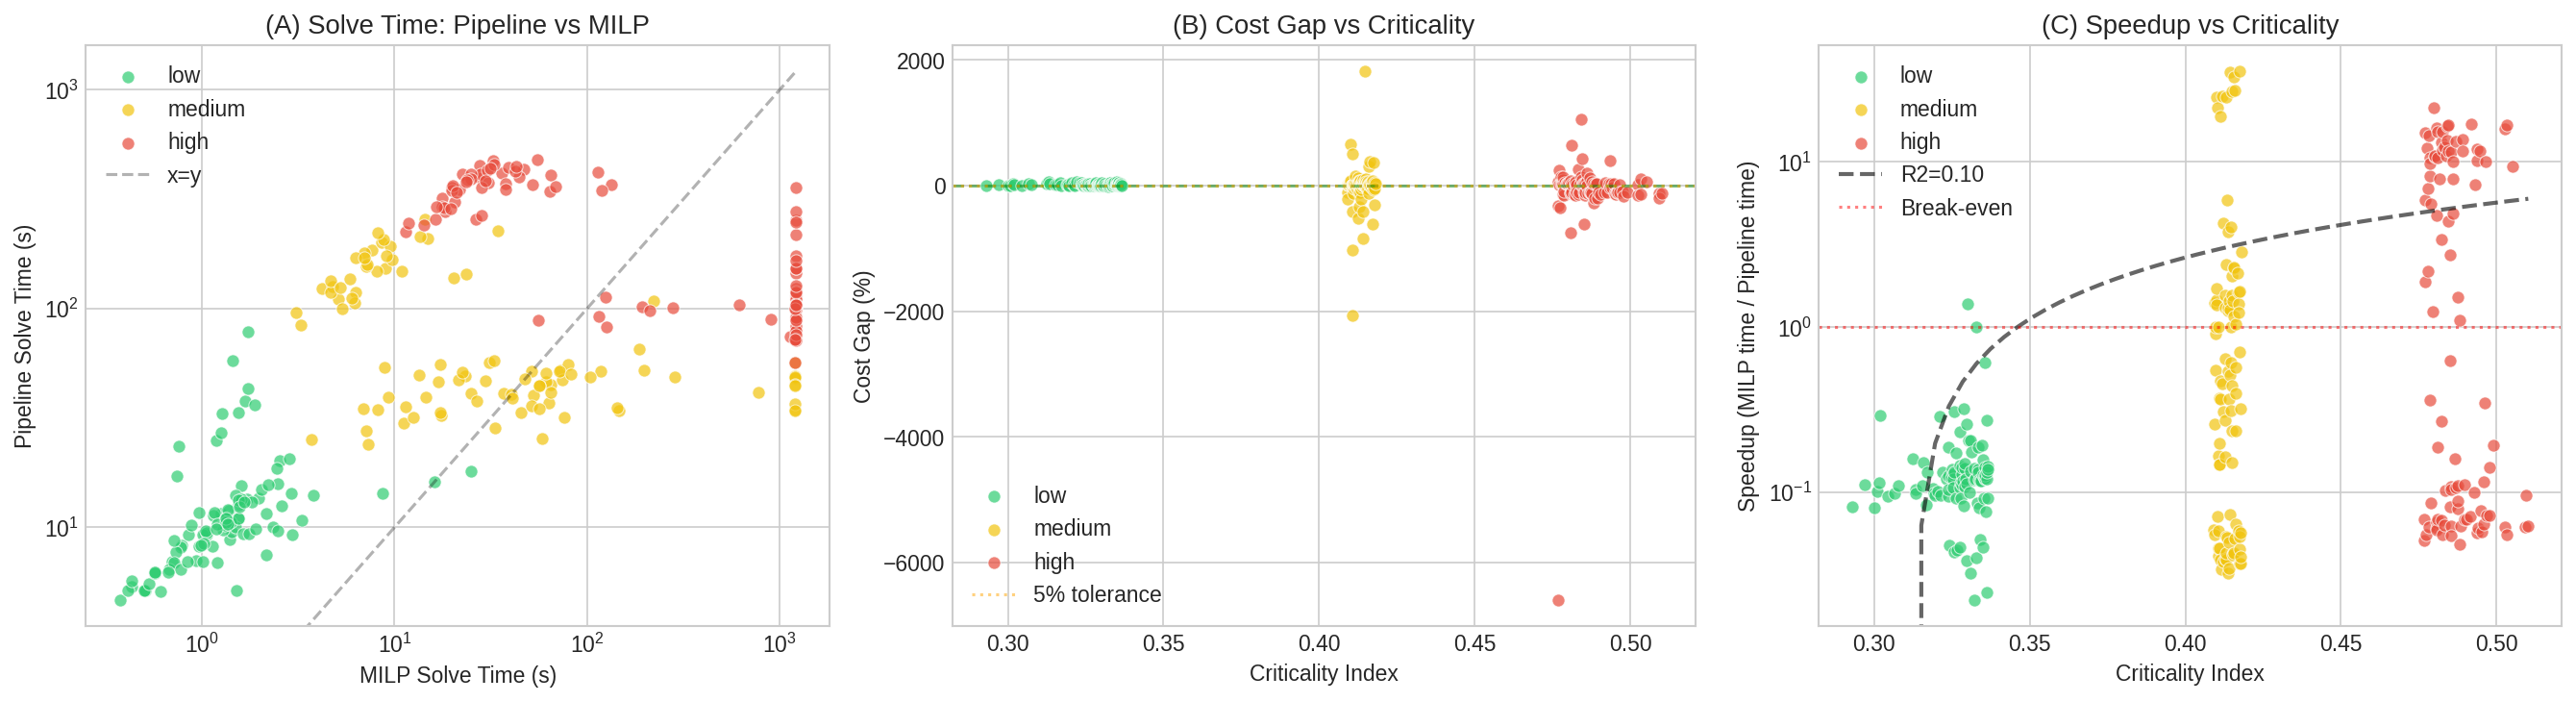

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

FAMILY_COLORS = {'low': '#2ecc71', 'medium': '#f1c40f', 'high': '#e74c3c'}
STAGE_COLORS = {'hard_fix': '#2ecc71', 'repair_20': '#f1c40f', 'repair_100': '#e67e22', 'full_soft': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel A: Solve Time Comparison ---
ax = axes[0]
for fam, color in FAMILY_COLORS.items():
    mask = df['family'] == fam
    ax.scatter(df.loc[mask, 'milp_solve_time'], df.loc[mask, 'pipeline_solve_time'],
              c=color, label=fam, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.plot([0, df['milp_solve_time'].max()], [0, df['milp_solve_time'].max()],
        'k--', alpha=0.3, label='x=y')
ax.set_xlabel('MILP Solve Time (s)')
ax.set_ylabel('Pipeline Solve Time (s)')
ax.set_title('(A) Solve Time: Pipeline vs MILP')
ax.legend()
ax.set_xscale('log'); ax.set_yscale('log')

# --- Panel B: Cost Gap vs Criticality ---
ax = axes[1]
for fam, color in FAMILY_COLORS.items():
    mask = df['family'] == fam
    ax.scatter(df.loc[mask, 'criticality_index'], df.loc[mask, 'cost_gap_pct'],
              c=color, label=fam, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.axhline(y=0, color='green', linestyle='--', alpha=0.5)
ax.axhline(y=5, color='orange', linestyle=':', alpha=0.5, label='5% tolerance')
ax.set_xlabel('Criticality Index')
ax.set_ylabel('Cost Gap (%)')
ax.set_title('(B) Cost Gap vs Criticality')
ax.legend()

# --- Panel C: Speedup vs Criticality ---
ax = axes[2]
for fam, color in FAMILY_COLORS.items():
    mask = df['family'] == fam
    ax.scatter(df.loc[mask, 'criticality_index'], df.loc[mask, 'speedup'],
              c=color, label=fam, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
# Regression
valid = df.dropna(subset=['criticality_index', 'speedup'])
if len(valid) > 3:
    slope, intercept, r_val, p_val, _ = stats.linregress(valid['criticality_index'], valid['speedup'])
    x_line = np.linspace(valid['criticality_index'].min(), valid['criticality_index'].max(), 50)
    ax.plot(x_line, slope * x_line + intercept, 'k--', lw=2, alpha=0.6,
            label=f'R2={r_val**2:.2f}')
ax.axhline(y=1, color='red', linestyle=':', alpha=0.5, label='Break-even')
ax.set_xlabel('Criticality Index')
ax.set_ylabel('Speedup (MILP time / Pipeline time)')
ax.set_title('(C) Speedup vs Criticality')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_solve_time_cost_gap_speedup.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Stage Distribution by Family

/tmp/ipython-input-848226940.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_boxes, labels=['Low', 'Medium', 'High'],


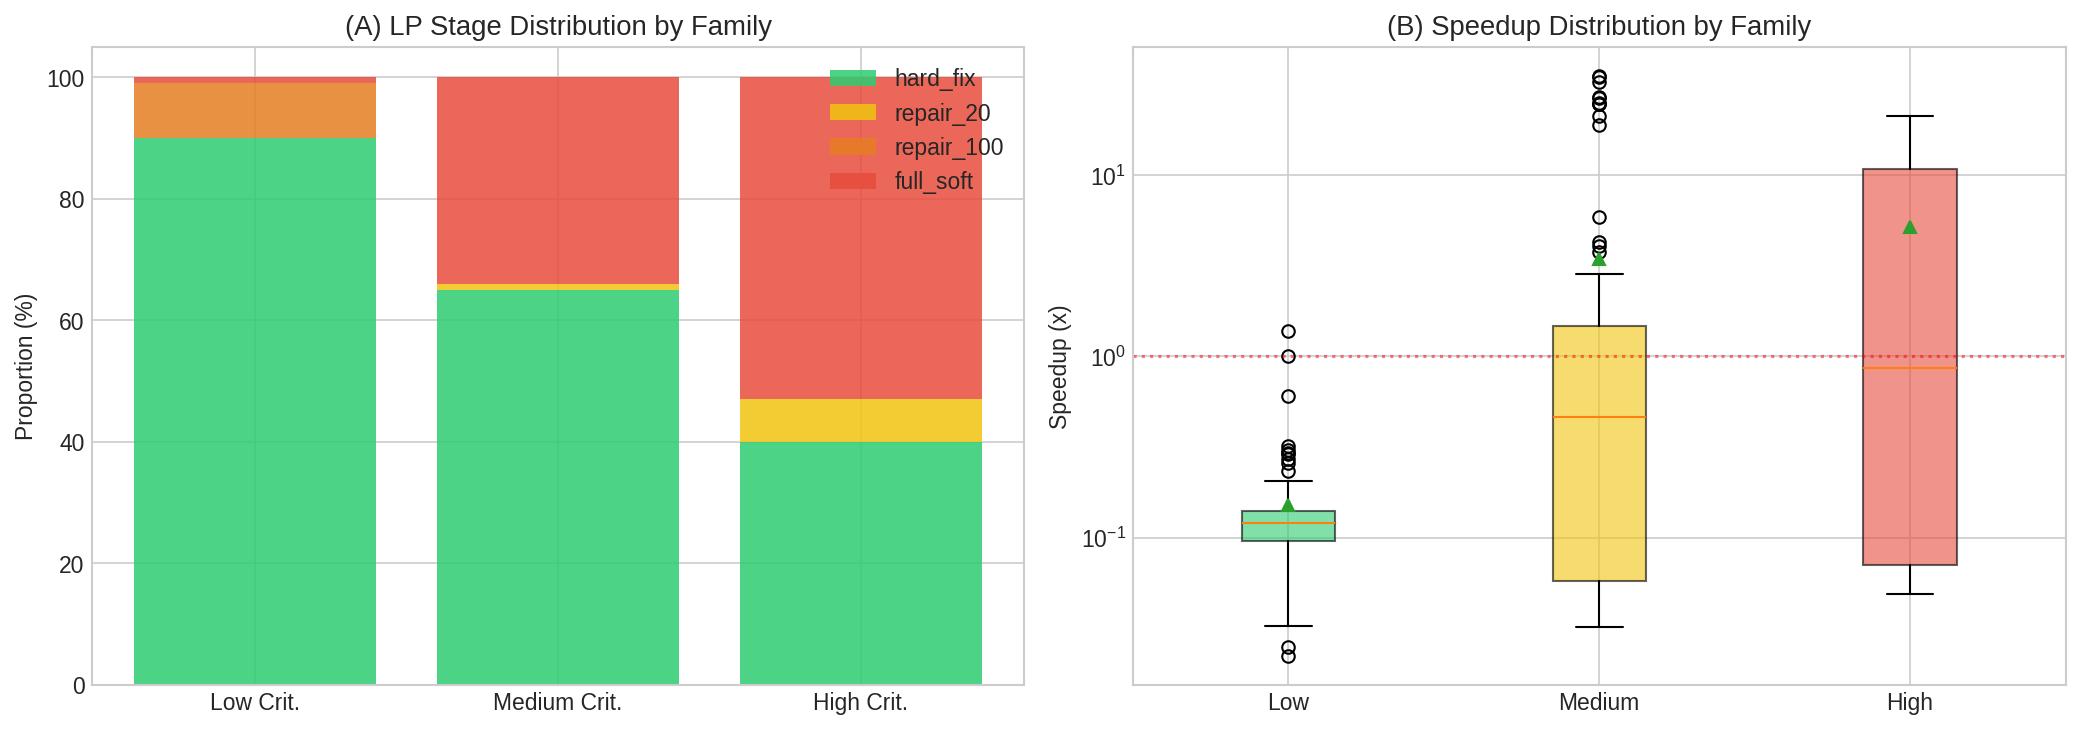

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel A: Stacked bar by family ---
ax = axes[0]
stages = ['hard_fix', 'repair_20', 'repair_100', 'full_soft']
families_list = ['low', 'medium', 'high']
x = np.arange(len(families_list))
bottom = np.zeros(len(families_list))

for stage in stages:
    values = []
    for fam in families_list:
        fam_df = df[df['family'] == fam]
        count = (fam_df['pipeline_stage'] == stage).sum()
        values.append(count / max(len(fam_df), 1) * 100)
    ax.bar(x, values, bottom=bottom, label=stage,
           color=STAGE_COLORS.get(stage, 'gray'), alpha=0.85)
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(['Low Crit.', 'Medium Crit.', 'High Crit.'])
ax.set_ylabel('Proportion (%)')
ax.set_title('(A) LP Stage Distribution by Family')
ax.legend(loc='upper right')
ax.set_ylim(0, 105)

# --- Panel B: Speedup boxplot by family ---
ax = axes[1]
data_boxes = [df[df['family'] == fam]['speedup'].dropna() for fam in families_list]
bp = ax.boxplot(data_boxes, labels=['Low', 'Medium', 'High'],
                patch_artist=True, showmeans=True)
for patch, fam in zip(bp['boxes'], families_list):
    patch.set_facecolor(FAMILY_COLORS[fam])
    patch.set_alpha(0.6)
ax.set_ylabel('Speedup (x)')
ax.set_title('(B) Speedup Distribution by Family')
ax.set_yscale('log')
ax.axhline(y=1, color='red', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_stage_distribution_speedup.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Pareto Frontier: Quality vs Speed

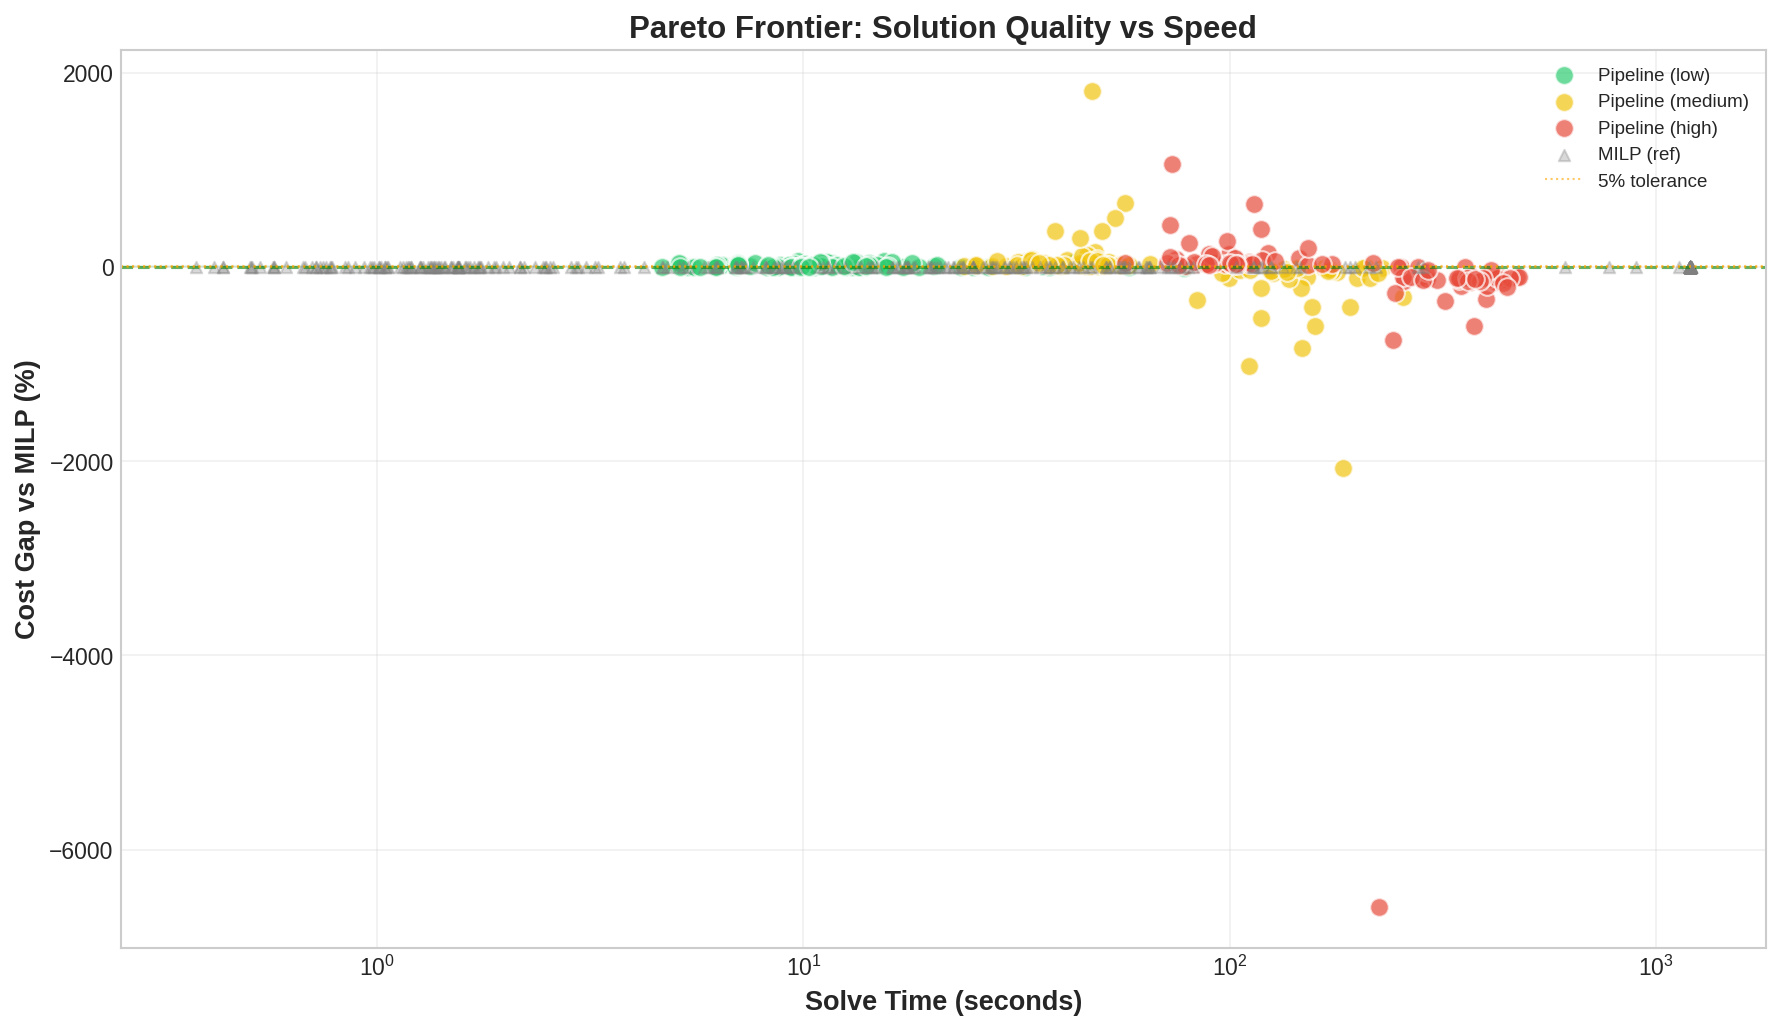

Pareto-optimal (|gap|<5%, time<120s): 37/300


In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

for fam, color in FAMILY_COLORS.items():
    mask = df['family'] == fam
    ax.scatter(df.loc[mask, 'pipeline_solve_time'], df.loc[mask, 'cost_gap_pct'],
              c=color, label=f'Pipeline ({fam})', s=80, alpha=0.7,
              edgecolors='white', linewidth=1)

# MILP reference (all at their solve time, gap=0)
ax.scatter(df['milp_solve_time'], [0]*len(df), c='gray', label='MILP (ref)',
          s=30, alpha=0.3, marker='^')

ax.axhline(y=0, color='green', linestyle='--', lw=1.5, alpha=0.6)
ax.axhline(y=5, color='orange', linestyle=':', lw=1, alpha=0.6, label='5% tolerance')
ax.axhline(y=-5, color='orange', linestyle=':', lw=1, alpha=0.6)

ax.set_xlabel('Solve Time (seconds)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cost Gap vs MILP (%)', fontsize=13, fontweight='bold')
ax.set_title('Pareto Frontier: Solution Quality vs Speed', fontsize=15, fontweight='bold')
ax.set_xscale('log')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Highlight Pareto-optimal region
ax.axhspan(-5, 5, xmin=0, xmax=0.3, alpha=0.08, color='green')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_pareto_quality_speed.png', dpi=300, bbox_inches='tight')
plt.show()

# Count Pareto-optimal
pareto = (df['cost_gap_pct'].abs() < 5) & (df['pipeline_solve_time'] < 120)
print(f'Pareto-optimal (|gap|<5%, time<120s): {pareto.sum()}/{len(df)}')

## 11. Economic Advantage Indicator

**Formula:**
$$\text{Total Cost}_{\text{method}} = C_{\text{solution}} + \lambda \cdot T_{\text{solve}}$$

$$\text{Advantage} = \text{Total Cost}_{\text{MILP}} - \text{Total Cost}_{\text{Pipeline}}$$

Where $\lambda$ (EUR/second) is the operational cost of waiting (outage risk, standby cost, market opportunity cost).

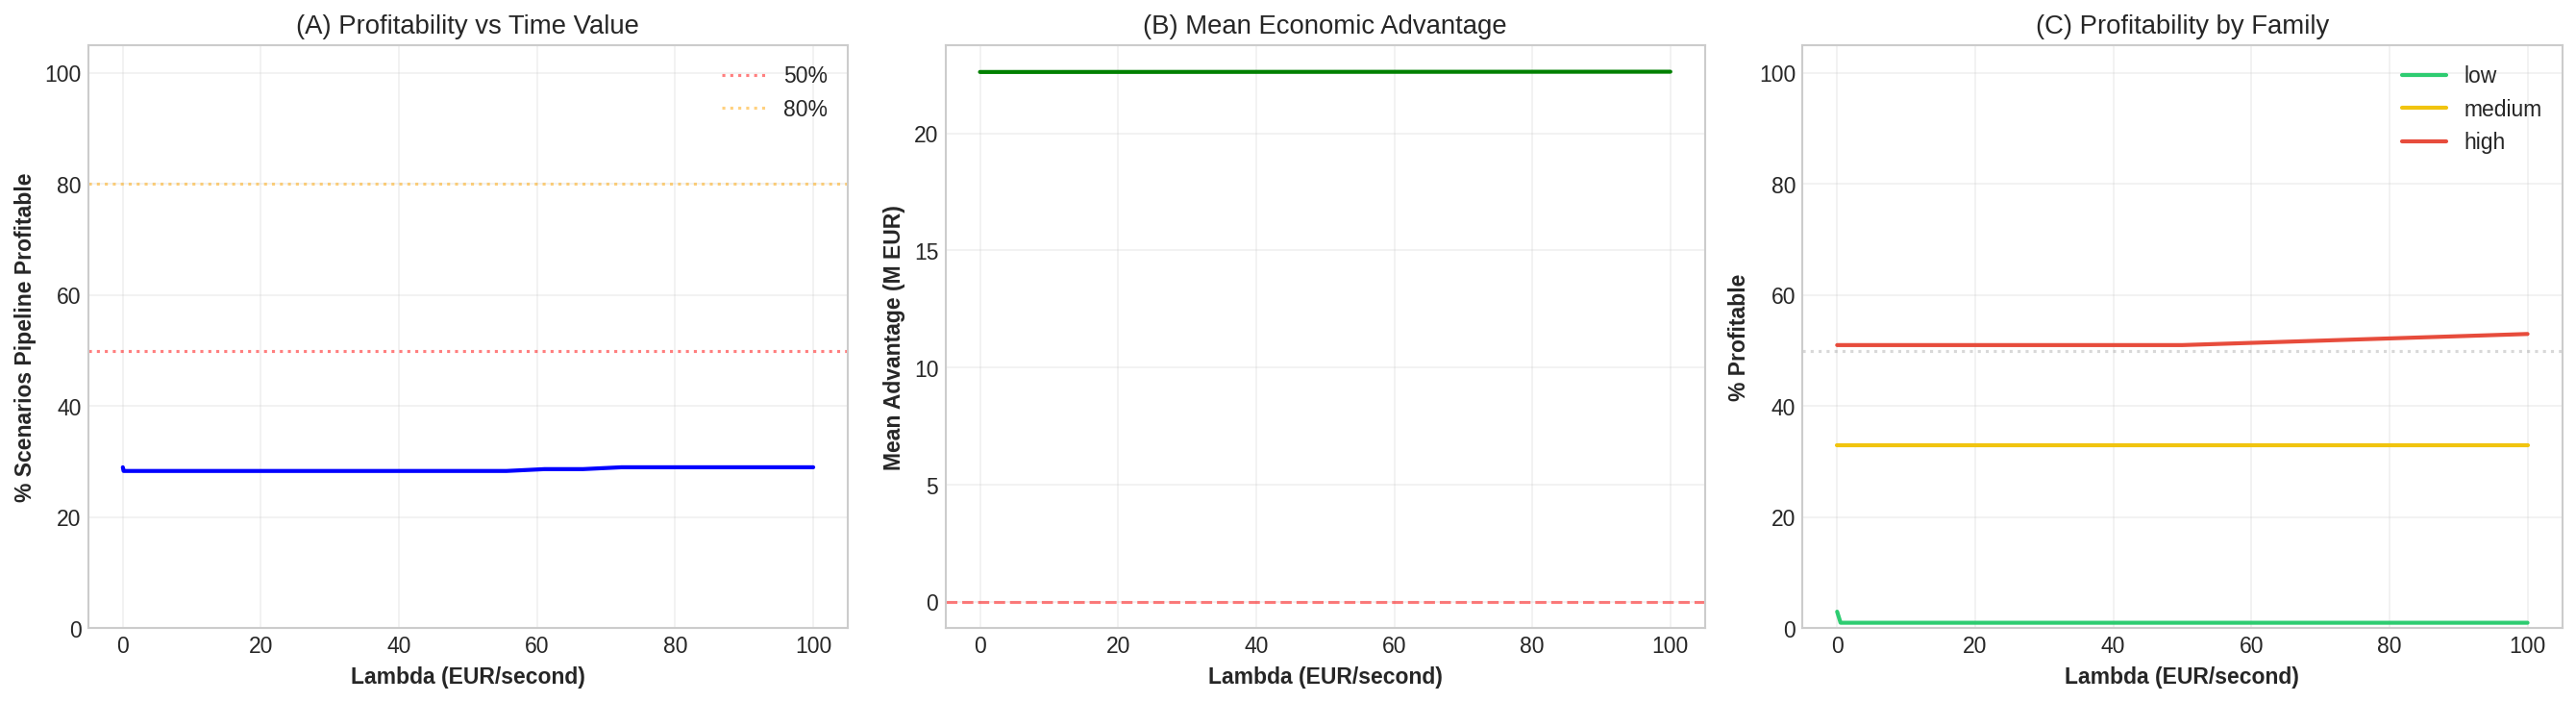

In [12]:
from src.eval.economic_advantage import EconomicAdvantageAnalyzer

econ = EconomicAdvantageAnalyzer(df)

# Global sensitivity analysis
sensitivity_df = econ.sensitivity_analysis()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel A: % Profitable vs Lambda ---
ax = axes[0]
ax.plot(sensitivity_df['lambda'], sensitivity_df['pct_profitable'], 'b-', lw=2)
ax.axhline(y=50, color='red', linestyle=':', alpha=0.5, label='50%')
ax.axhline(y=80, color='orange', linestyle=':', alpha=0.5, label='80%')
ax.set_xlabel('Lambda (EUR/second)', fontweight='bold')
ax.set_ylabel('% Scenarios Pipeline Profitable', fontweight='bold')
ax.set_title('(A) Profitability vs Time Value')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

# --- Panel B: Mean Advantage vs Lambda ---
ax = axes[1]
ax.plot(sensitivity_df['lambda'], sensitivity_df['mean_advantage'] / 1e6, 'g-', lw=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Lambda (EUR/second)', fontweight='bold')
ax.set_ylabel('Mean Advantage (M EUR)', fontweight='bold')
ax.set_title('(B) Mean Economic Advantage')
ax.grid(True, alpha=0.3)

# --- Panel C: Sensitivity by Family ---
ax = axes[2]
family_sens = econ.sensitivity_by_family()
for fam_name, fam_df in family_sens.items():
    color = FAMILY_COLORS.get(fam_name, 'gray')
    ax.plot(fam_df['lambda'], fam_df['pct_profitable'], '-', color=color, lw=2, label=fam_name)
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('Lambda (EUR/second)', fontweight='bold')
ax.set_ylabel('% Profitable', fontweight='bold')
ax.set_title('(C) Profitability by Family')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_economic_advantage.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Breakeven Lambda Analysis

In [13]:
# Find breakeven lambda values
summary = econ.compute_summary(lambda_values=[1, 5, 10, 20, 50, 100])

print('='*60)
print('ECONOMIC ADVANTAGE SUMMARY')
print('='*60)
print(f"Breakeven lambda (50% profitable): {summary['breakeven_lambda_50pct']:.2f} EUR/s")
print(f"Breakeven lambda (80% profitable): {summary['breakeven_lambda_80pct']:.2f} EUR/s")
print(f"Breakeven lambda (95% profitable): {summary['breakeven_lambda_95pct']:.2f} EUR/s")

print(f"\nPer-family breakeven (50%):")
for fam, lam in summary['family_breakevens'].items():
    print(f"  {fam}: {lam:.2f} EUR/s")

print(f"\nAt selected lambda values:")
for key, val in summary.items():
    if key.startswith('lambda_'):
        lam = key.replace('lambda_', '')
        print(f"  lambda={lam} EUR/s: {val['pct_profitable']:.1f}% profitable, "
              f"mean advantage={val['mean_advantage_eur']/1e6:.2f} MEUR")

ECONOMIC ADVANTAGE SUMMARY
Breakeven lambda (50% profitable): 1000.00 EUR/s
Breakeven lambda (80% profitable): 1000.00 EUR/s
Breakeven lambda (95% profitable): 1000.00 EUR/s

Per-family breakeven (50%):
  low: 1000.00 EUR/s
  medium: 1000.00 EUR/s
  high: 0.00 EUR/s

At selected lambda values:
  lambda=1 EUR/s: 28.3% profitable, mean advantage=22.62 MEUR
  lambda=5 EUR/s: 28.3% profitable, mean advantage=22.62 MEUR
  lambda=10 EUR/s: 28.3% profitable, mean advantage=22.62 MEUR
  lambda=20 EUR/s: 28.3% profitable, mean advantage=22.62 MEUR
  lambda=50 EUR/s: 28.3% profitable, mean advantage=22.63 MEUR
  lambda=100 EUR/s: 29.0% profitable, mean advantage=22.63 MEUR


## 13. Lambda Sensitivity Heatmap

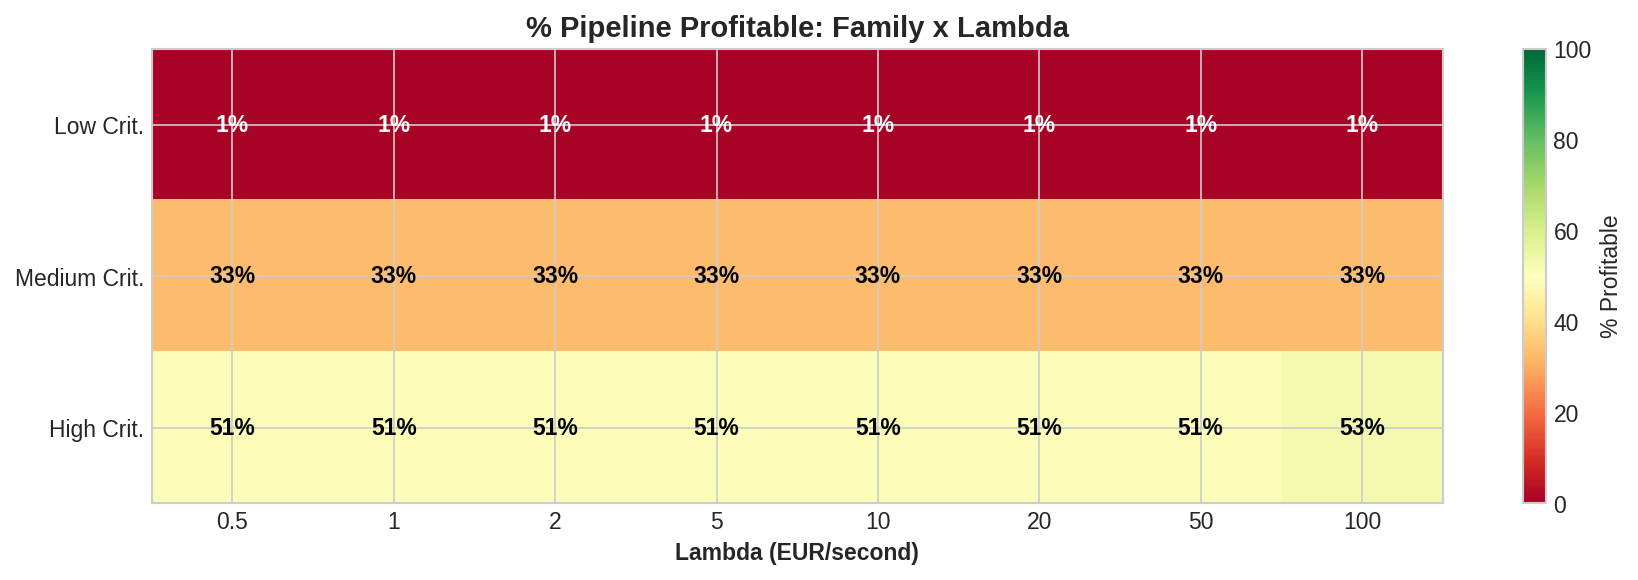

In [14]:
lambda_values = [0.5, 1, 2, 5, 10, 20, 50, 100]
families_list = ['low', 'medium', 'high']

# Build heatmap data: rows=families, cols=lambda, values=pct_profitable
heat_data = np.zeros((len(families_list), len(lambda_values)))
for i, fam in enumerate(families_list):
    sub_df = df[df['family'] == fam]
    sub_econ = EconomicAdvantageAnalyzer(sub_df)
    for j, lam in enumerate(lambda_values):
        adv_df = sub_econ.compute_advantage(lam)
        valid = adv_df.dropna(subset=['advantage'])
        heat_data[i, j] = valid['pipeline_profitable'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(heat_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(lambda_values)))
ax.set_xticklabels([f'{l}' for l in lambda_values])
ax.set_yticks(range(len(families_list)))
ax.set_yticklabels(['Low Crit.', 'Medium Crit.', 'High Crit.'])
ax.set_xlabel('Lambda (EUR/second)', fontweight='bold')
ax.set_title('% Pipeline Profitable: Family x Lambda', fontsize=14, fontweight='bold')

# Annotate cells
for i in range(len(families_list)):
    for j in range(len(lambda_values)):
        val = heat_data[i, j]
        color = 'white' if val < 30 or val > 70 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', color=color, fontweight='bold')

plt.colorbar(im, ax=ax, label='% Profitable')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_lambda_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Cumulative Time Savings

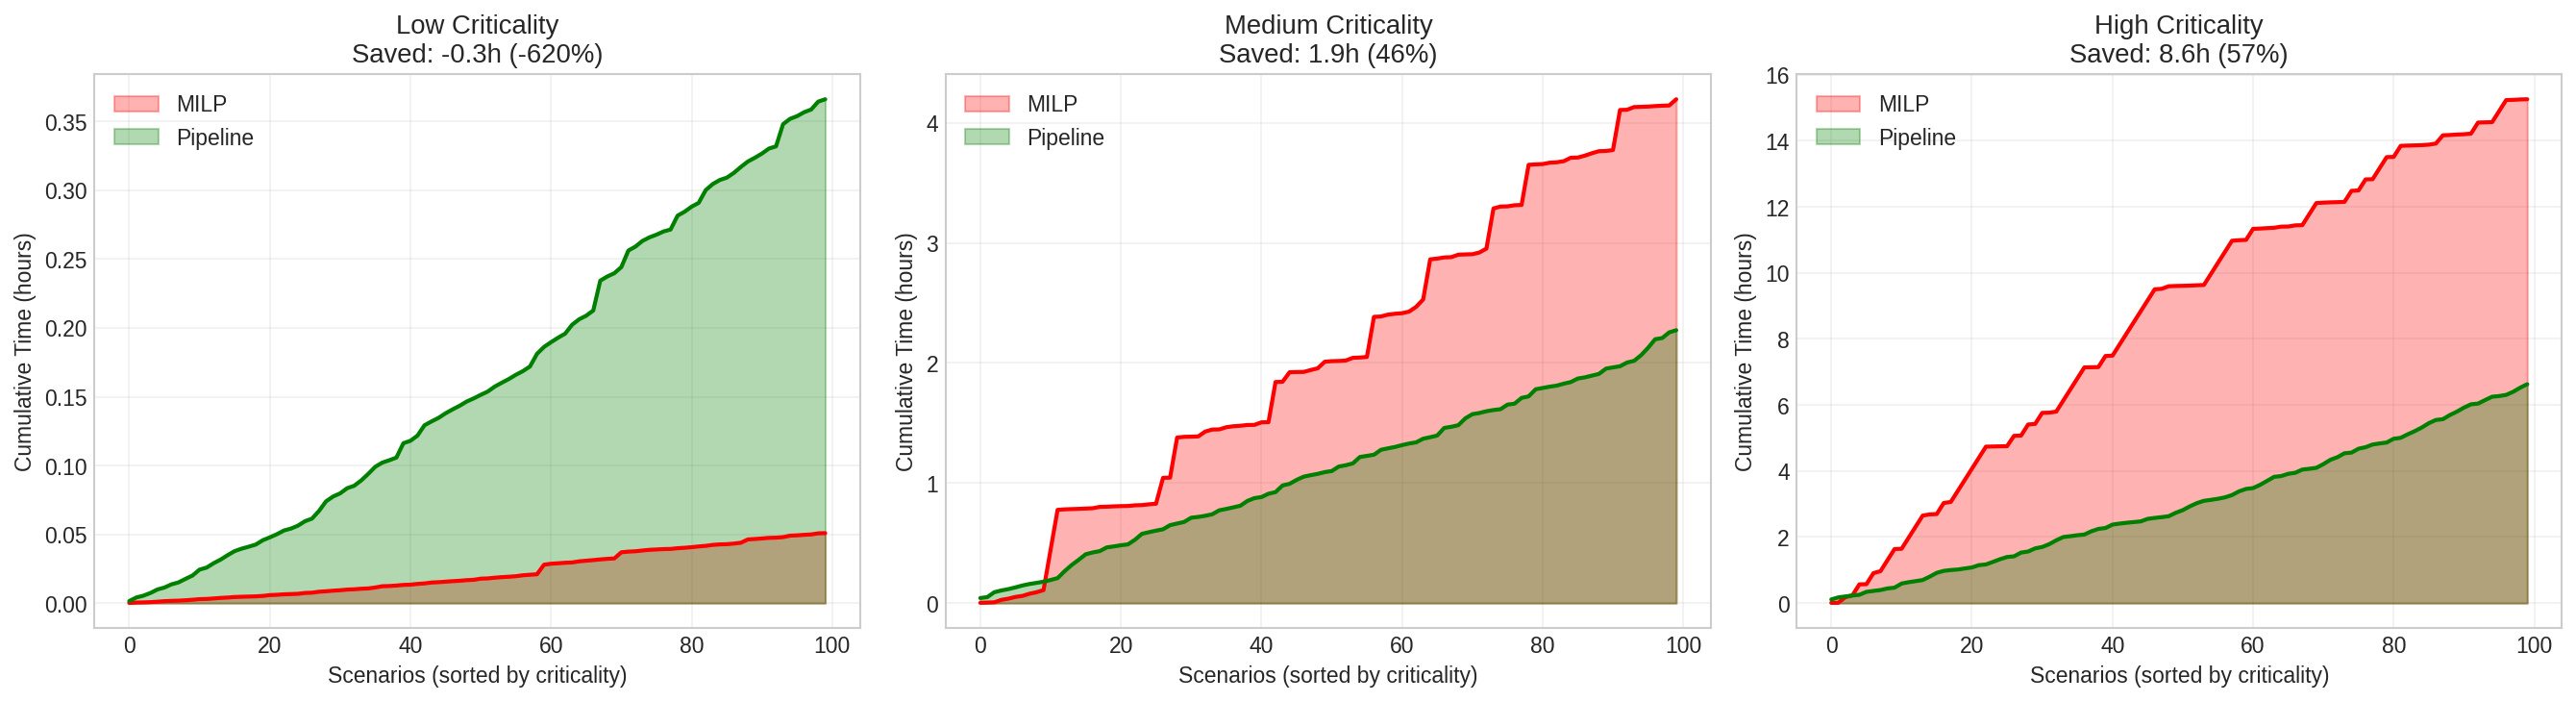

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, fam in enumerate(families_list):
    ax = axes[idx]
    fam_df = df[df['family'] == fam].sort_values('criticality_index').reset_index(drop=True)

    cum_milp = fam_df['milp_solve_time'].cumsum() / 3600
    cum_pipe = fam_df['pipeline_solve_time'].cumsum() / 3600

    ax.fill_between(range(len(fam_df)), cum_milp, alpha=0.3, color='red', label='MILP')
    ax.fill_between(range(len(fam_df)), cum_pipe, alpha=0.3, color='green', label='Pipeline')
    ax.plot(range(len(fam_df)), cum_milp, 'r-', lw=2)
    ax.plot(range(len(fam_df)), cum_pipe, 'g-', lw=2)

    total_milp = cum_milp.iloc[-1] if len(cum_milp) > 0 else 0
    total_pipe = cum_pipe.iloc[-1] if len(cum_pipe) > 0 else 0
    saved = total_milp - total_pipe
    pct_saved = saved / max(total_milp, 1e-9) * 100

    ax.set_xlabel('Scenarios (sorted by criticality)')
    ax.set_ylabel('Cumulative Time (hours)')
    ax.set_title(f'{fam.capitalize()} Criticality\nSaved: {saved:.1f}h ({pct_saved:.0f}%)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_cumulative_time.png', dpi=300, bbox_inches='tight')
plt.show()

## 15. Pipeline Timing Breakdown

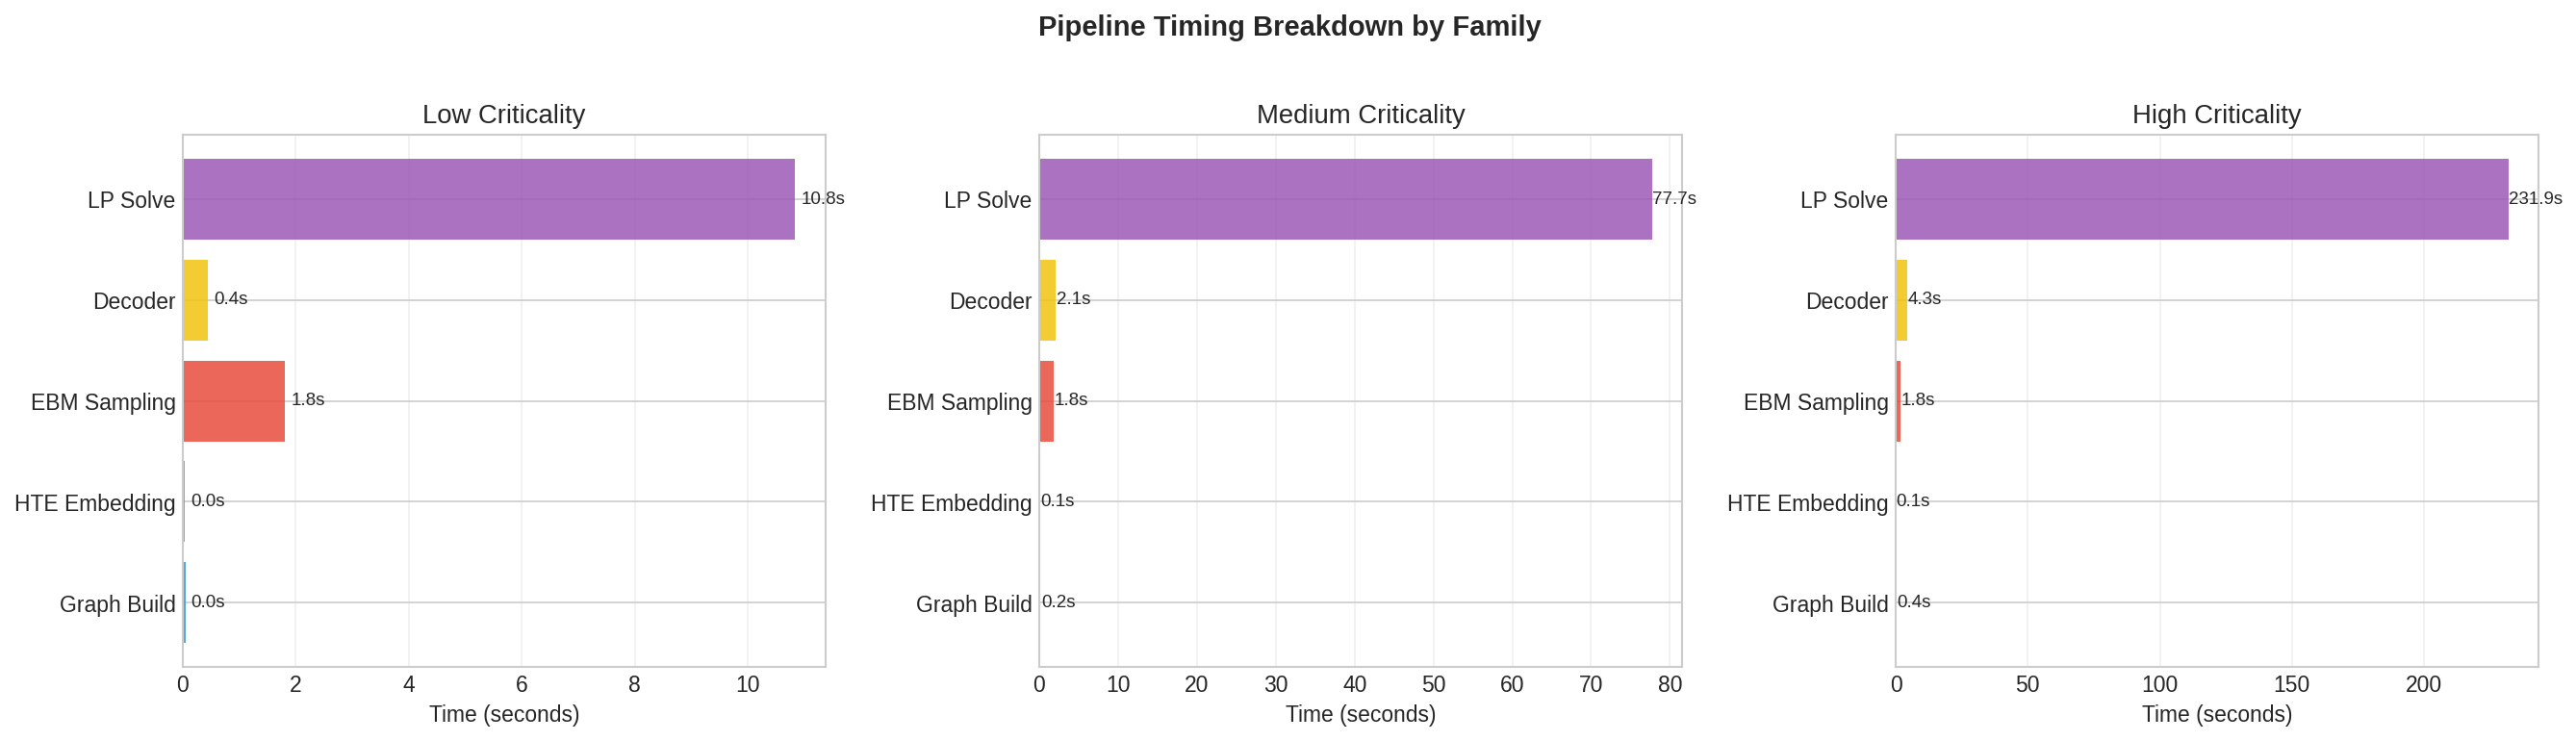

In [16]:
timing_cols = ['time_graph_build', 'time_embedding', 'time_ebm_sampling', 'time_decoder', 'time_lp_solve']
timing_labels = ['Graph Build', 'HTE Embedding', 'EBM Sampling', 'Decoder', 'LP Solve']
timing_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, fam in enumerate(families_list):
    ax = axes[idx]
    fam_df = df[df['family'] == fam]
    means = [fam_df[col].mean() for col in timing_cols]

    ax.barh(timing_labels, means, color=timing_colors, alpha=0.85)
    for i, v in enumerate(means):
        ax.text(v + 0.1, i, f'{v:.1f}s', va='center', fontsize=9)
    ax.set_xlabel('Time (seconds)')
    ax.set_title(f'{fam.capitalize()} Criticality')
    ax.grid(True, alpha=0.3, axis='x')

fig.suptitle('Pipeline Timing Breakdown by Family', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig7_timing_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

## 16. Criticality Index Distribution

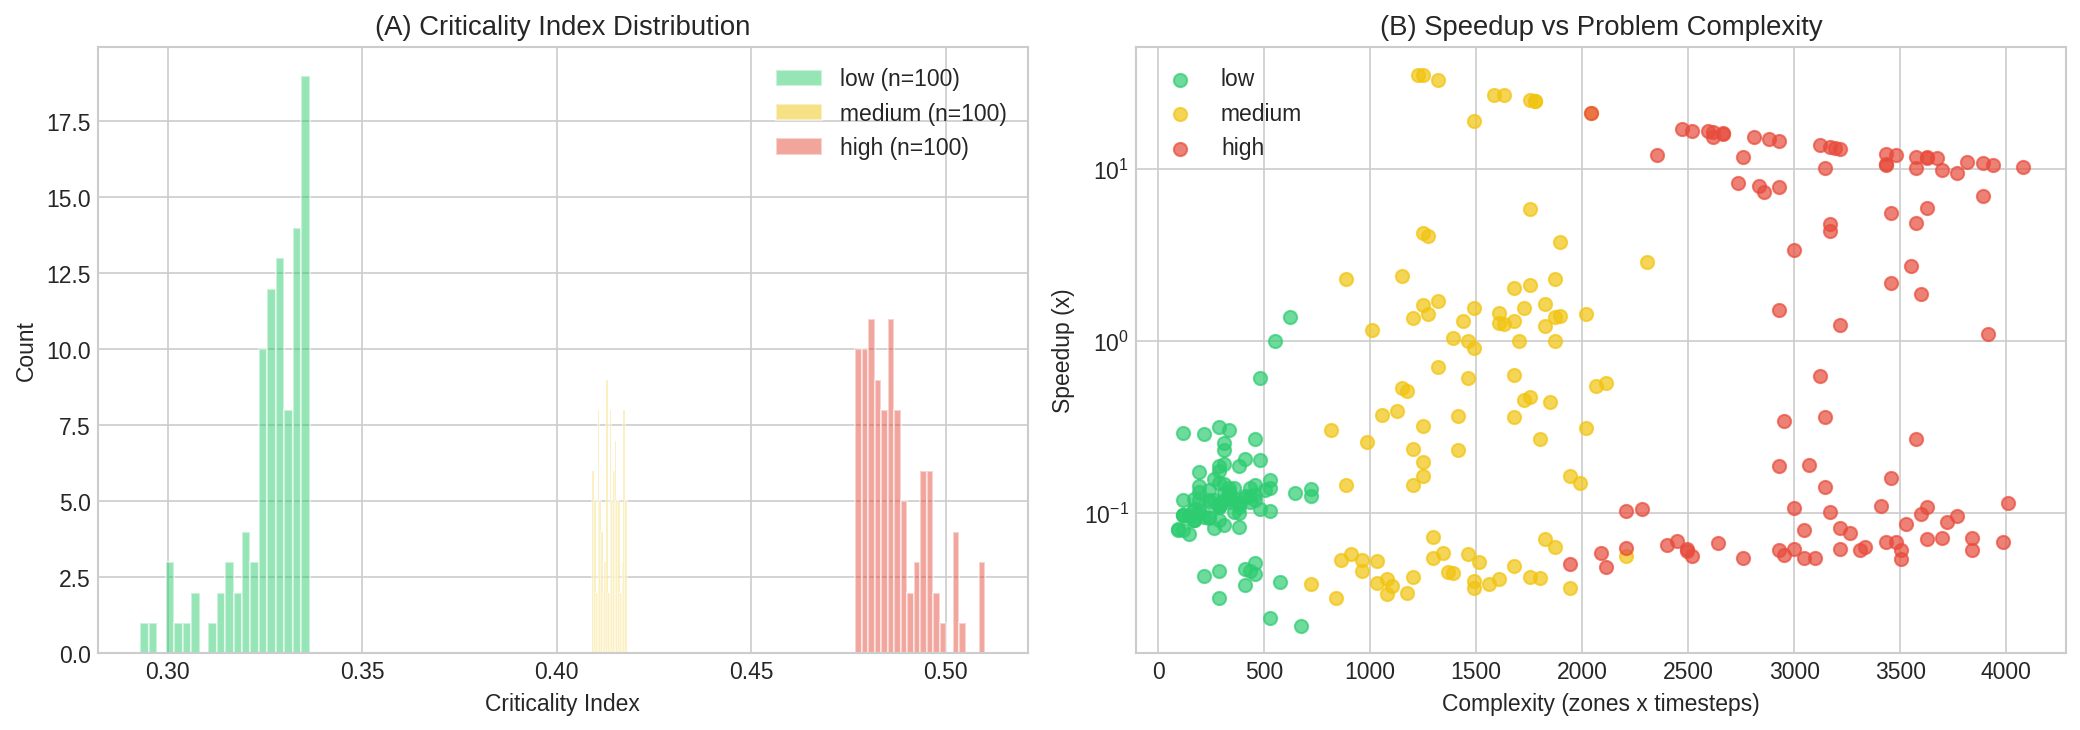

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel A: Criticality Distribution ---
ax = axes[0]
for fam, color in FAMILY_COLORS.items():
    fam_df = df[df['family'] == fam]
    ax.hist(fam_df['criticality_index'], bins=20, alpha=0.5, color=color,
            label=f'{fam} (n={len(fam_df)})', edgecolor='white')
ax.set_xlabel('Criticality Index')
ax.set_ylabel('Count')
ax.set_title('(A) Criticality Index Distribution')
ax.legend()

# --- Panel B: Complexity (n_zones * n_timesteps) ---
ax = axes[1]
df['complexity'] = df['n_zones'] * df['n_timesteps']
for fam, color in FAMILY_COLORS.items():
    mask = df['family'] == fam
    ax.scatter(df.loc[mask, 'complexity'], df.loc[mask, 'speedup'],
              c=color, label=fam, s=40, alpha=0.7)
ax.set_xlabel('Complexity (zones x timesteps)')
ax.set_ylabel('Speedup (x)')
ax.set_title('(B) Speedup vs Problem Complexity')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig8_criticality_complexity.png', dpi=300, bbox_inches='tight')
plt.show()

## 17. Final Summary Table

In [18]:
# Build summary table
summary_rows = []
for fam in families_list:
    fam_df = df[df['family'] == fam]
    valid = fam_df.dropna(subset=['speedup', 'cost_gap_pct'])

    row = {
        'Family': fam.capitalize(),
        'N': len(fam_df),
        'Success': f"{fam_df['success'].mean()*100:.0f}%",
        'Crit. Index (mean)': f"{fam_df['criticality_index'].mean():.3f}",
        'Speedup (median)': f"{valid['speedup'].median():.1f}x",
        'Cost Gap P50': f"{valid['cost_gap_pct'].median():.1f}%",
        'Cost Gap P90': f"{np.percentile(valid['cost_gap_pct'], 90):.1f}%" if len(valid) > 0 else 'N/A',
        'Cost Gap P99': f"{np.percentile(valid['cost_gap_pct'], 99):.1f}%" if len(valid) > 0 else 'N/A',
        'Pipeline Time (mean)': f"{fam_df['pipeline_solve_time'].mean():.1f}s",
        'MILP Time (mean)': f"{fam_df['milp_solve_time'].mean():.1f}s",
        'Hard Fix %': f"{(fam_df['pipeline_stage']=='hard_fix').mean()*100:.0f}%",
    }
    summary_rows.append(row)

# Add global row
valid_all = df.dropna(subset=['speedup', 'cost_gap_pct'])
summary_rows.append({
    'Family': 'ALL',
    'N': len(df),
    'Success': f"{df['success'].mean()*100:.0f}%",
    'Crit. Index (mean)': f"{df['criticality_index'].mean():.3f}",
    'Speedup (median)': f"{valid_all['speedup'].median():.1f}x",
    'Cost Gap P50': f"{valid_all['cost_gap_pct'].median():.1f}%",
    'Cost Gap P90': f"{np.percentile(valid_all['cost_gap_pct'], 90):.1f}%" if len(valid_all) > 0 else 'N/A',
    'Cost Gap P99': f"{np.percentile(valid_all['cost_gap_pct'], 99):.1f}%" if len(valid_all) > 0 else 'N/A',
    'Pipeline Time (mean)': f"{df['pipeline_solve_time'].mean():.1f}s",
    'MILP Time (mean)': f"{df['milp_solve_time'].mean():.1f}s",
    'Hard Fix %': f"{(df['pipeline_stage']=='hard_fix').mean()*100:.0f}%",
})

summary_table = pd.DataFrame(summary_rows)
print('\n' + '='*90)
print('FINAL EVALUATION SUMMARY')
print('='*90)
print(summary_table.to_string(index=False))

# Save
summary_table.to_csv(OUTPUT_DIR / 'summary_table.csv', index=False)
df.to_csv(OUTPUT_DIR / 'full_comparison.csv', index=False)
print(f'\nResults saved to {OUTPUT_DIR}')


FINAL EVALUATION SUMMARY
Family   N Success Crit. Index (mean) Speedup (median) Cost Gap P50 Cost Gap P90 Cost Gap P99 Pipeline Time (mean) MILP Time (mean) Hard Fix %
   Low 100    100%              0.326             0.1x        12.6%        41.6%        61.4%                13.2s             1.8s        90%
Medium 100    100%              0.414             0.5x        18.5%        78.2%       669.8%                81.8s           151.1s        65%
  High 100    100%              0.487             0.9x        -0.0%       118.3%       651.0%               238.7s           549.3s        40%
   ALL 300    100%              0.409             0.1x        14.4%        67.7%       647.1%               111.2s           234.1s        65%

Results saved to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_criticality


## 18. Save All Figures and Data

In [19]:
# Save economic analysis results
econ_summary = econ.compute_summary(lambda_values=[0.5, 1, 2, 5, 10, 20, 50, 100])
with open(OUTPUT_DIR / 'economic_summary.json', 'w') as f:
    json.dump(econ_summary, f, indent=2, default=str)

# Save sensitivity data
sensitivity_df.to_csv(OUTPUT_DIR / 'lambda_sensitivity.csv', index=False)

# Save per-family sensitivity
for fam_name, fam_sens_df in family_sens.items():
    fam_sens_df.to_csv(OUTPUT_DIR / f'lambda_sensitivity_{fam_name}.csv', index=False)

# Save full metrics
eval_metrics_serializable = {
    k: v for k, v in eval_output.items() if k != 'dataframe'
}
with open(OUTPUT_DIR / 'eval_metrics.json', 'w') as f:
    json.dump(eval_metrics_serializable, f, indent=2, default=str)

print(f'All outputs saved to: {OUTPUT_DIR}')
print('\nFiles:')
for f in sorted(OUTPUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name}: {size_kb:.1f} KB')

All outputs saved to: /content/drive/MyDrive/benchmark/outputs/pipeline_eval_criticality

Files:
  economic_summary.json: 1.5 KB
  eval_metrics.json: 8.2 KB
  fig10_htl_cost_gap.png: 376.9 KB
  fig11_htl_economic_advantage.png: 237.6 KB
  fig1_solve_time_cost_gap_speedup.png: 650.9 KB
  fig2_stage_distribution_speedup.png: 157.8 KB
  fig3_pareto_quality_speed.png: 347.2 KB
  fig4_economic_advantage.png: 188.5 KB
  fig5_lambda_heatmap.png: 108.2 KB
  fig6_cumulative_time.png: 293.1 KB
  fig7_timing_breakdown.png: 159.2 KB
  fig8_criticality_complexity.png: 432.1 KB
  fig9_htl_speed_analysis.png: 316.8 KB
  full_comparison.csv: 92.7 KB
  graphs: 4.0 KB
  high_crit_timelimit_comparison.csv: 12.9 KB
  lambda_sensitivity.csv: 7.3 KB
  lambda_sensitivity_high.csv: 1.3 KB
  lambda_sensitivity_low.csv: 1.3 KB
  lambda_sensitivity_medium.csv: 1.3 KB
  pipeline_eval_all_families.pkl: 69.7 KB
  summary_table.csv: 0.4 KB


## 19. Focused Analysis: High-Criticality MaxTimeLimit Scenarios

The pipeline's value proposition is strongest on MILP-hard scenarios that hit the solver time limit.
This section isolates the **high-criticality MaxTimeLimit** subset and computes:
1. Corrected comparison DataFrame (with family-aware MILP matching)
2. Speed analysis
3. Cost gap analysis
4. Economic advantage with lambda sensitivity

In [20]:
# --- Rebuild DataFrame with corrected MILP matching (family-prefixed keys) ---
from src.eval.metrics import compute_eval_metrics, format_metrics_table

milp_reports_dirs = {name: paths['reports_dir'] for name, paths in FAMILIES.items()}
eval_output = compute_eval_metrics(pipeline_results, milp_reports_dirs)
df = eval_output['dataframe']

# Sanity check: MILP times should now differ across families
print("MILP solve time per family (sanity check):")
for fam in ['low', 'medium', 'high']:
    fam_df = df[df['family'] == fam]
    print(f"  {fam}: MILP mean={fam_df['milp_solve_time'].mean():.1f}s, "
          f"Pipeline mean={fam_df['pipeline_solve_time'].mean():.1f}s")

# Filter: High-criticality + MaxTimeLimit only
df_htl = df[(df['family'] == 'high') & (df['milp_termination'] == 'maxTimeLimit')].copy()
print(f"\nHigh-crit MaxTimeLimit scenarios: {len(df_htl)} / {len(df[df['family'] == 'high'])} high-crit total")
print(f"Pipeline solve time: mean={df_htl['pipeline_solve_time'].mean():.1f}s, "
      f"median={df_htl['pipeline_solve_time'].median():.1f}s")
print(f"MILP solve time (all ~1200s): mean={df_htl['milp_solve_time'].mean():.1f}s")
print(f"Speedup: mean={df_htl['speedup'].mean():.1f}x, median={df_htl['speedup'].median():.1f}x")

MILP solve time per family (sanity check):
  low: MILP mean=1.8s, Pipeline mean=13.2s
  medium: MILP mean=151.1s, Pipeline mean=81.8s
  high: MILP mean=549.3s, Pipeline mean=238.7s

High-crit MaxTimeLimit scenarios: 41 / 100 high-crit total
Pipeline solve time: mean=124.6s, median=103.9s
MILP solve time (all ~1200s): mean=1205.6s
Speedup: mean=11.4x, median=11.6x


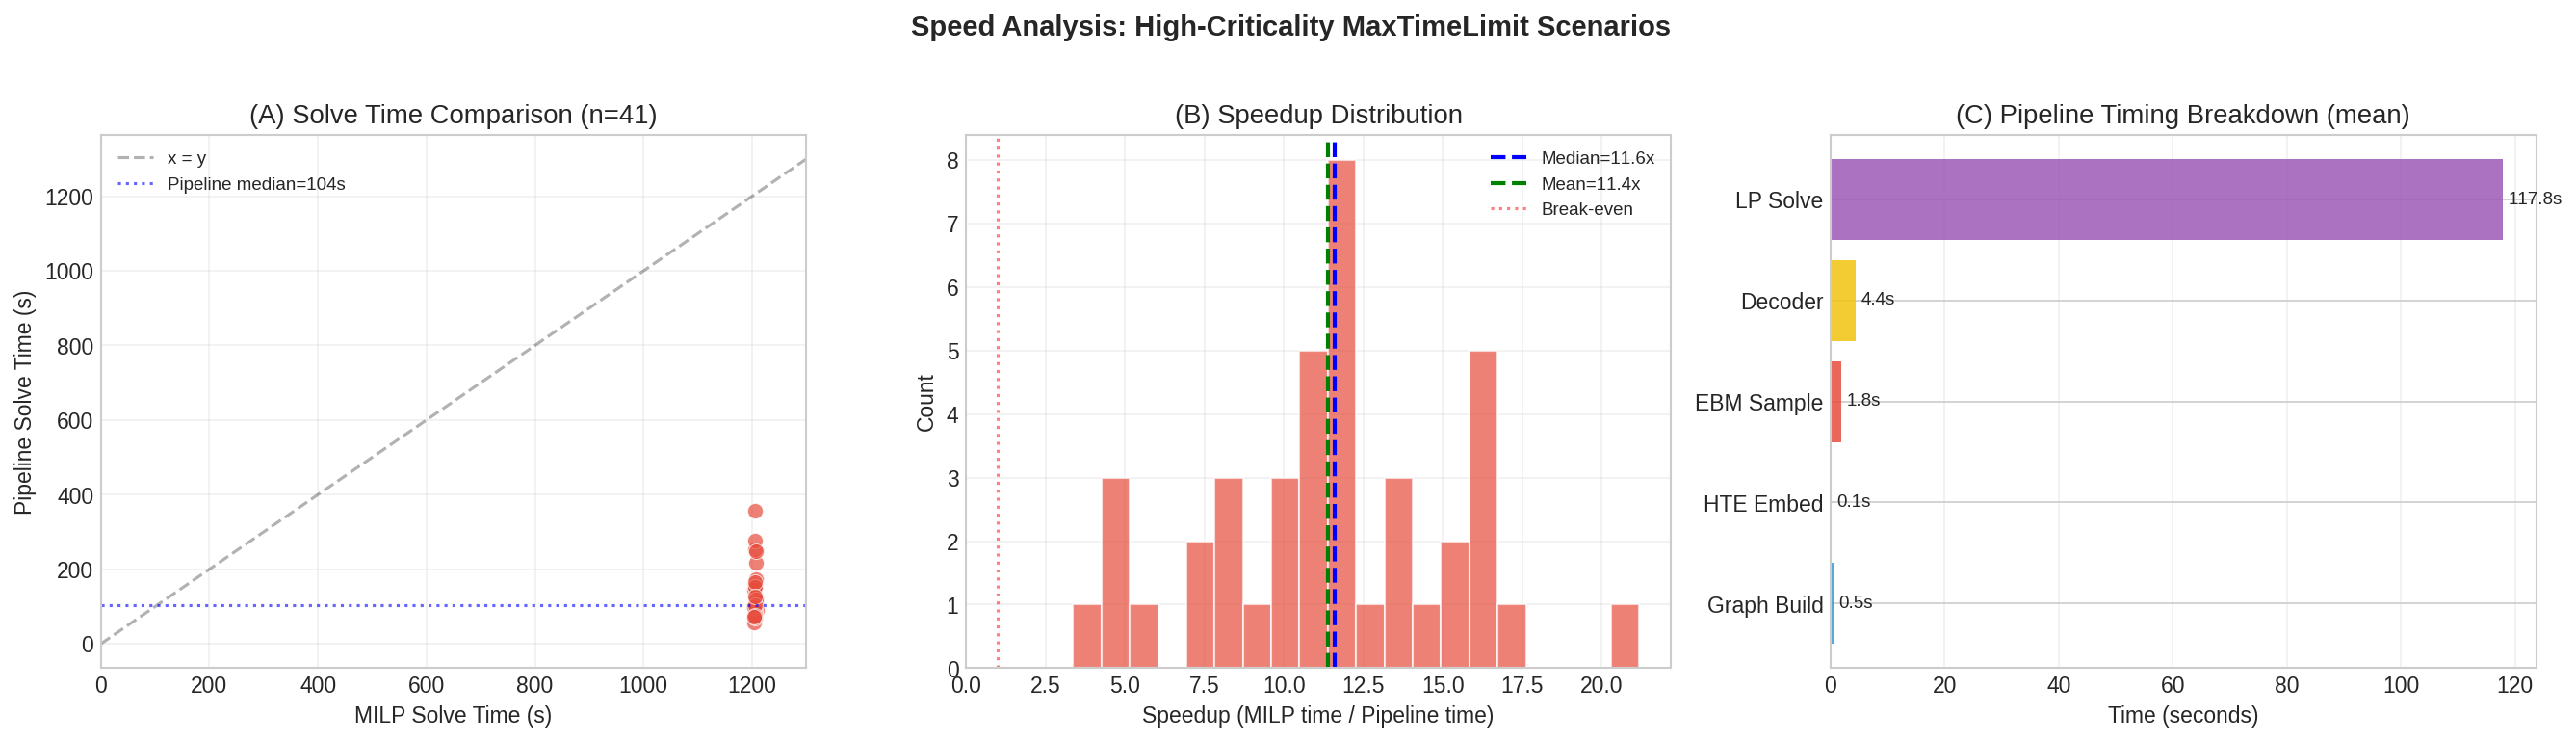

Speedup stats:
  Min: 3.37x
  P25: 9.46x
  Median: 11.61x
  P75: 13.70x
  Max: 21.17x
  % faster than MILP: 100%


In [21]:
# --- Speed Analysis: High-Crit MaxTimeLimit ---
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Pipeline vs MILP solve time (scatter)
ax = axes[0]
ax.scatter(df_htl['milp_solve_time'], df_htl['pipeline_solve_time'],
           c='#e74c3c', s=60, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.plot([0, 1300], [0, 1300], 'k--', alpha=0.3, label='x = y')
ax.axhline(y=df_htl['pipeline_solve_time'].median(), color='blue',
           linestyle=':', alpha=0.6, label=f"Pipeline median={df_htl['pipeline_solve_time'].median():.0f}s")
ax.set_xlabel('MILP Solve Time (s)')
ax.set_ylabel('Pipeline Solve Time (s)')
ax.set_title(f'(A) Solve Time Comparison (n={len(df_htl)})')
ax.legend(fontsize=9)
ax.set_xlim(0, 1300)
ax.grid(True, alpha=0.3)

# Panel B: Speedup distribution
ax = axes[1]
ax.hist(df_htl['speedup'], bins=20, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.axvline(x=df_htl['speedup'].median(), color='blue', linestyle='--', lw=2,
           label=f"Median={df_htl['speedup'].median():.1f}x")
ax.axvline(x=df_htl['speedup'].mean(), color='green', linestyle='--', lw=2,
           label=f"Mean={df_htl['speedup'].mean():.1f}x")
ax.axvline(x=1, color='red', linestyle=':', alpha=0.5, label='Break-even')
ax.set_xlabel('Speedup (MILP time / Pipeline time)')
ax.set_ylabel('Count')
ax.set_title('(B) Speedup Distribution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel C: Pipeline time breakdown (stacked bar)
ax = axes[2]
timing_cols = ['time_graph_build', 'time_embedding', 'time_ebm_sampling', 'time_decoder', 'time_lp_solve']
timing_labels = ['Graph Build', 'HTE Embed', 'EBM Sample', 'Decoder', 'LP Solve']
timing_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f1c40f', '#9b59b6']
means = [df_htl[col].mean() for col in timing_cols]
bars = ax.barh(timing_labels, means, color=timing_colors, alpha=0.85)
for bar, v in zip(bars, means):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v:.1f}s', va='center', fontsize=9)
ax.set_xlabel('Time (seconds)')
ax.set_title(f'(C) Pipeline Timing Breakdown (mean)')
ax.grid(True, alpha=0.3, axis='x')

fig.suptitle('Speed Analysis: High-Criticality MaxTimeLimit Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig9_htl_speed_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print stats
print(f"Speedup stats:")
print(f"  Min: {df_htl['speedup'].min():.2f}x")
print(f"  P25: {df_htl['speedup'].quantile(0.25):.2f}x")
print(f"  Median: {df_htl['speedup'].median():.2f}x")
print(f"  P75: {df_htl['speedup'].quantile(0.75):.2f}x")
print(f"  Max: {df_htl['speedup'].max():.2f}x")
print(f"  % faster than MILP: {(df_htl['speedup'] > 1).mean()*100:.0f}%")

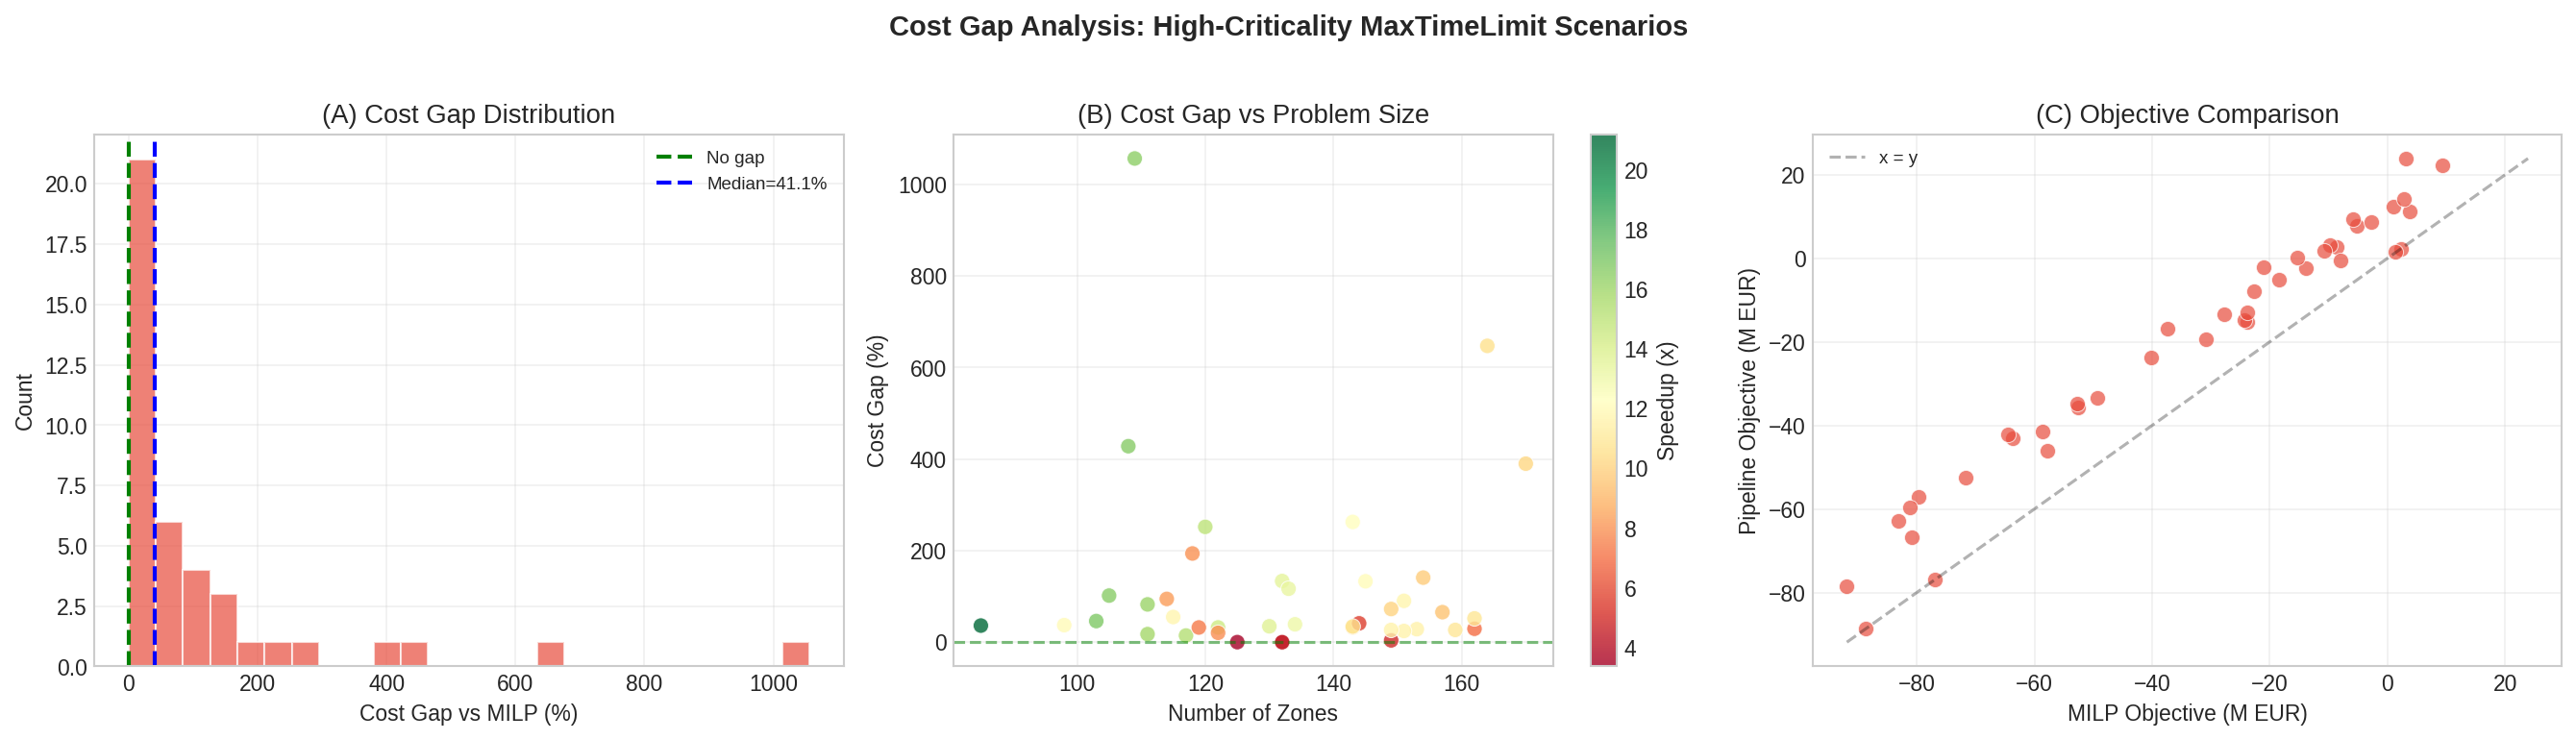

Cost gap stats (pipeline vs MILP best incumbent):
  Mean: 120.1%
  Median: 41.1%
  P10: 14.5%
  P90: 262.5%
  Pipeline better (gap < 0): 2/41 (5%)
  Within 5%: 4/41
  Within 10%: 4/41

LP Stage distribution:
  hard_fix: 30 (73%)
  repair_20: 7 (17%)
  full_soft: 4 (10%)


In [22]:
# --- Cost Gap Analysis: High-Crit MaxTimeLimit ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Cost gap distribution
ax = axes[0]
ax.hist(df_htl['cost_gap_pct'], bins=25, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.axvline(x=0, color='green', linestyle='--', lw=2, label='No gap')
ax.axvline(x=df_htl['cost_gap_pct'].median(), color='blue', linestyle='--', lw=2,
           label=f"Median={df_htl['cost_gap_pct'].median():.1f}%")
ax.set_xlabel('Cost Gap vs MILP (%)')
ax.set_ylabel('Count')
ax.set_title('(A) Cost Gap Distribution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel B: Cost gap vs n_zones
ax = axes[1]
sc = ax.scatter(df_htl['n_zones'], df_htl['cost_gap_pct'],
                c=df_htl['speedup'], cmap='RdYlGn', s=60, alpha=0.8,
                edgecolors='white', linewidth=0.5)
ax.axhline(y=0, color='green', linestyle='--', alpha=0.5)
ax.set_xlabel('Number of Zones')
ax.set_ylabel('Cost Gap (%)')
ax.set_title('(B) Cost Gap vs Problem Size')
plt.colorbar(sc, ax=ax, label='Speedup (x)')
ax.grid(True, alpha=0.3)

# Panel C: Pipeline obj vs MILP obj (scatter)
ax = axes[2]
ax.scatter(df_htl['milp_objective'] / 1e6, df_htl['pipeline_objective'] / 1e6,
           c='#e74c3c', s=60, alpha=0.7, edgecolors='white', linewidth=0.5)
obj_range = [min(df_htl['milp_objective'].min(), df_htl['pipeline_objective'].min()) / 1e6,
             max(df_htl['milp_objective'].max(), df_htl['pipeline_objective'].max()) / 1e6]
ax.plot(obj_range, obj_range, 'k--', alpha=0.3, label='x = y')
ax.set_xlabel('MILP Objective (M EUR)')
ax.set_ylabel('Pipeline Objective (M EUR)')
ax.set_title('(C) Objective Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle('Cost Gap Analysis: High-Criticality MaxTimeLimit Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig10_htl_cost_gap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print stats
print(f"Cost gap stats (pipeline vs MILP best incumbent):")
print(f"  Mean: {df_htl['cost_gap_pct'].mean():.1f}%")
print(f"  Median: {df_htl['cost_gap_pct'].median():.1f}%")
print(f"  P10: {df_htl['cost_gap_pct'].quantile(0.10):.1f}%")
print(f"  P90: {df_htl['cost_gap_pct'].quantile(0.90):.1f}%")
print(f"  Pipeline better (gap < 0): {(df_htl['cost_gap_pct'] < 0).sum()}/{len(df_htl)} "
      f"({(df_htl['cost_gap_pct'] < 0).mean()*100:.0f}%)")
print(f"  Within 5%: {(df_htl['cost_gap_pct'].abs() < 5).sum()}/{len(df_htl)}")
print(f"  Within 10%: {(df_htl['cost_gap_pct'].abs() < 10).sum()}/{len(df_htl)}")

# Stage distribution for this subset
print(f"\nLP Stage distribution:")
for stage, count in df_htl['pipeline_stage'].value_counts().items():
    print(f"  {stage}: {count} ({count/len(df_htl)*100:.0f}%)")

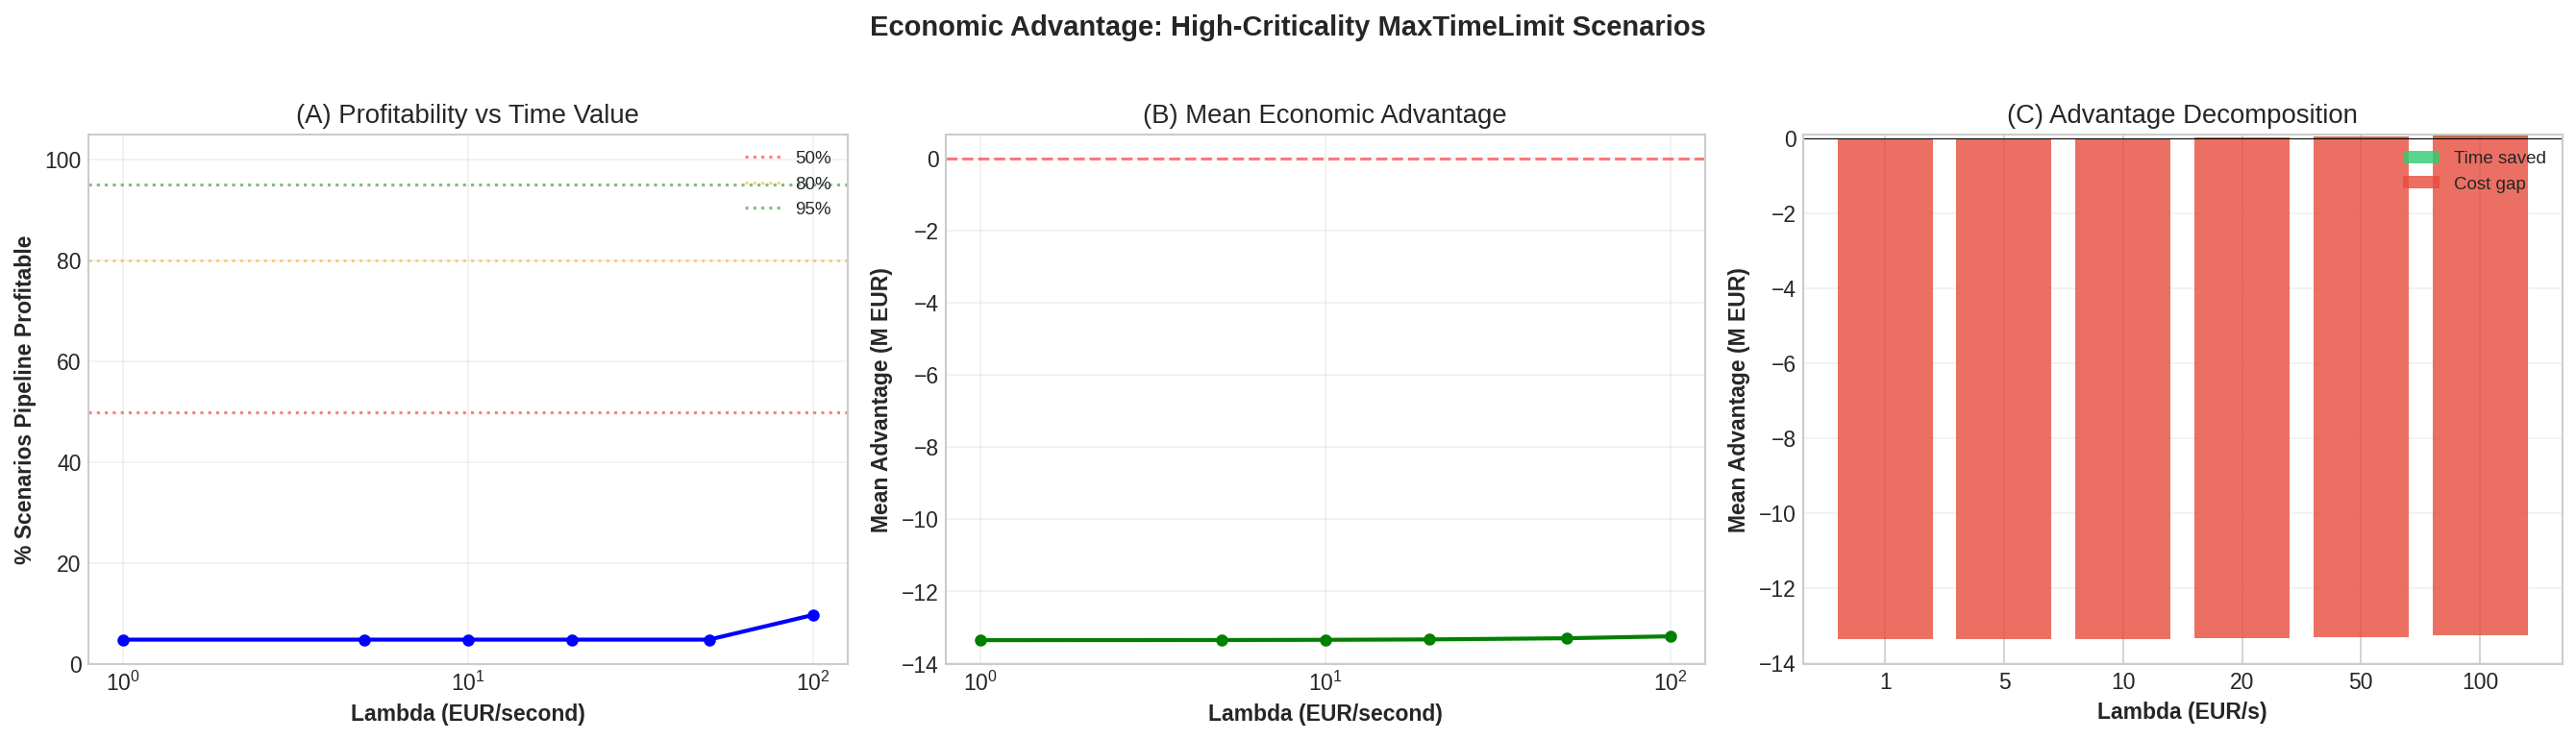

ECONOMIC ADVANTAGE: High-Crit MaxTimeLimit (n=41)
Breakeven lambda (50% profitable): 1000.00 EUR/s
Breakeven lambda (80% profitable): 1000.00 EUR/s
Breakeven lambda (95% profitable): 1000.00 EUR/s

At selected lambda values:
  lambda=   1 EUR/s:   4.9% profitable, mean advantage=-13.35 MEUR
  lambda=  10 EUR/s:   4.9% profitable, mean advantage=-13.34 MEUR
  lambda= 100 EUR/s:   9.8% profitable, mean advantage=-13.25 MEUR
  lambda=  20 EUR/s:   4.9% profitable, mean advantage=-13.33 MEUR
  lambda=   5 EUR/s:   4.9% profitable, mean advantage=-13.35 MEUR
  lambda=  50 EUR/s:   4.9% profitable, mean advantage=-13.30 MEUR


In [23]:
# --- Economic Advantage: High-Crit MaxTimeLimit ---
from src.eval.economic_advantage import EconomicAdvantageAnalyzer

econ_htl = EconomicAdvantageAnalyzer(df_htl)

# Sensitivity analysis
lambda_values = [1, 5, 10, 20, 50, 100]
sens_htl = econ_htl.sensitivity_analysis(lambda_values=lambda_values)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: % Profitable vs Lambda
ax = axes[0]
ax.plot(sens_htl['lambda'], sens_htl['pct_profitable'], 'b-o', lw=2, markersize=5)
ax.axhline(y=50, color='red', linestyle=':', alpha=0.5, label='50%')
ax.axhline(y=80, color='orange', linestyle=':', alpha=0.5, label='80%')
ax.axhline(y=95, color='green', linestyle=':', alpha=0.5, label='95%')
ax.set_xlabel('Lambda (EUR/second)', fontweight='bold')
ax.set_ylabel('% Scenarios Pipeline Profitable', fontweight='bold')
ax.set_title('(A) Profitability vs Time Value')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)
ax.set_xscale('log')

# Panel B: Mean Advantage vs Lambda
ax = axes[1]
ax.plot(sens_htl['lambda'], sens_htl['mean_advantage'] / 1e6, 'g-o', lw=2, markersize=5)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Lambda (EUR/second)', fontweight='bold')
ax.set_ylabel('Mean Advantage (M EUR)', fontweight='bold')
ax.set_title('(B) Mean Economic Advantage')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# Panel C: Advantage decomposition at selected lambda
ax = axes[2]
selected_lambdas = [1, 5, 10, 20, 50, 100]
for lam in selected_lambdas:
    adv_df = econ_htl.compute_advantage(lam)
    valid = adv_df.dropna(subset=['advantage'])
    time_component = valid['advantage_from_time'].mean() / 1e6
    cost_component = valid['advantage_from_cost'].mean() / 1e6
    ax.bar(f'{lam}', time_component, color='#2ecc71', alpha=0.8, label='Time saved' if lam == selected_lambdas[0] else '')
    ax.bar(f'{lam}', cost_component, bottom=time_component, color='#e74c3c', alpha=0.8,
           label='Cost gap' if lam == selected_lambdas[0] else '')

ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_xlabel('Lambda (EUR/s)', fontweight='bold')
ax.set_ylabel('Mean Advantage (M EUR)', fontweight='bold')
ax.set_title('(C) Advantage Decomposition')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Economic Advantage: High-Criticality MaxTimeLimit Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig11_htl_economic_advantage.png', dpi=300, bbox_inches='tight')
plt.show()

# Breakeven analysis
summary_htl = econ_htl.compute_summary(lambda_values=[1, 5, 10, 20, 50, 100])
print('=' * 70)
print(f'ECONOMIC ADVANTAGE: High-Crit MaxTimeLimit (n={len(df_htl)})')
print('=' * 70)
print(f"Breakeven lambda (50% profitable): {summary_htl['breakeven_lambda_50pct']:.2f} EUR/s")
print(f"Breakeven lambda (80% profitable): {summary_htl['breakeven_lambda_80pct']:.2f} EUR/s")
print(f"Breakeven lambda (95% profitable): {summary_htl['breakeven_lambda_95pct']:.2f} EUR/s")
print(f"\nAt selected lambda values:")
for key, val in sorted(summary_htl.items()):
    if key.startswith('lambda_'):
        lam = key.replace('lambda_', '')
        print(f"  lambda={lam:>4s} EUR/s: {val['pct_profitable']:5.1f}% profitable, "
              f"mean advantage={val['mean_advantage_eur']/1e6:+.2f} MEUR")

In [24]:
# --- Summary Table: High-Crit MaxTimeLimit vs All High-Crit ---
df_high_all = df[df['family'] == 'high']
df_high_opt = df_high_all[df_high_all['milp_termination'] == 'optimal']

print('=' * 90)
print('HIGH-CRITICALITY: MaxTimeLimit vs Optimal vs All')
print('=' * 90)

for label, sub in [('MaxTimeLimit', df_htl), ('Optimal', df_high_opt), ('All High', df_high_all)]:
    valid = sub.dropna(subset=['speedup', 'cost_gap_pct'])
    n_better = (valid['cost_gap_pct'] < 0).sum()
    print(f"\n  {label} (n={len(sub)}):")
    print(f"    Pipeline time:  mean={sub['pipeline_solve_time'].mean():.1f}s, median={sub['pipeline_solve_time'].median():.1f}s")
    print(f"    MILP time:      mean={sub['milp_solve_time'].mean():.1f}s, median={sub['milp_solve_time'].median():.1f}s")
    print(f"    Speedup:        mean={valid['speedup'].mean():.1f}x, median={valid['speedup'].median():.1f}x")
    print(f"    Cost gap:       P50={valid['cost_gap_pct'].median():.1f}%, P90={np.percentile(valid['cost_gap_pct'], 90):.1f}%")
    print(f"    Pipeline better: {n_better}/{len(valid)} ({n_better/max(len(valid),1)*100:.0f}%)")
    print(f"    Stage dist:     {dict(sub['pipeline_stage'].value_counts())}")

# Save HTL subset
df_htl.to_csv(OUTPUT_DIR / 'high_crit_timelimit_comparison.csv', index=False)
print(f"\nSaved HTL subset to {OUTPUT_DIR / 'high_crit_timelimit_comparison.csv'}")

HIGH-CRITICALITY: MaxTimeLimit vs Optimal vs All

  MaxTimeLimit (n=41):
    Pipeline time:  mean=124.6s, median=103.9s
    MILP time:      mean=1205.6s, median=1205.8s
    Speedup:        mean=11.4x, median=11.6x
    Cost gap:       P50=41.1%, P90=262.5%
    Pipeline better: 2/41 (5%)
    Stage dist:     {'hard_fix': np.int64(30), 'repair_20': np.int64(7), 'full_soft': np.int64(4)}

  Optimal (n=59):
    Pipeline time:  mean=317.9s, median=356.3s
    MILP time:      mean=93.2s, median=30.6s
    Speedup:        mean=0.8x, median=0.1x
    Cost gap:       P50=-112.0%, P90=28.1%
    Pipeline better: 49/59 (83%)
    Stage dist:     {'full_soft': np.int64(49), 'hard_fix': np.int64(10)}

  All High (n=100):
    Pipeline time:  mean=238.7s, median=246.6s
    MILP time:      mean=549.3s, median=121.9s
    Speedup:        mean=5.1x, median=0.9x
    Cost gap:       P50=-0.0%, P90=118.3%
    Pipeline better: 51/100 (51%)
    Stage dist:     {'full_soft': np.int64(53), 'hard_fix': np.int64(40), 'r